## COL funtional visualization 012025 & 032024 reads

samples have been run through humann3 and identified genefamilies merged into 1 tsv (see  COL_functional_analysis_012025_032024.ipnyb)

In [1]:
#load libraries (not sure I need all these, but just in case)
library(tidyverse)
library(vegan)
library(phyloseq)
library(ggplot2)
library(RColorBrewer)
library(DESeq2)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following obj

In [2]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL"

In [2]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/humann3_functional_analysis_032024_012025/")

In [3]:
genes = read.csv("all_gene_families_rxn_cpm_named.csv")

In [4]:
head(genes)

,X..Gene.Family,X012025_COL_SAN_T5_568_OFAV_S1_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_569_DLAB_S2_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_570_DLAB_S3_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_571_DLAB_S4_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_572_OFAV_S5_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_573_PSTR_S6_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_574_MCAV_S7_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_575_DLAB_S8_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_576_PSTR_S9_comb_kraken_filtered_Abundance.CPM,⋯,X032024_COL_SAN_T5_150_MCAV_S8_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_154_PSTR_S38_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_158_DLAB_S15_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_159_DLAB_S16_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_160_DLAB_S41_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_161_DLAB_S42_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_162_PSTR_S39_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_163_PSTR_S11c_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_166_OFAV_S20_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_167_OFAV_S21_comb_kraken_filtered_Abundance.CPM
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,UNMAPPED,957318.00,986838.0,952221.00000,949848.00000,958649.0,9.730170e+05,984650.00,9.270780e+05,987116.00,⋯,959563.00000,982681.00,988575.00,989112.00,984053.00,9.471220e+05,979649.000,985808.0,956785.00,960071.00
2,UNGROUPED,42546.16,12621.9,43910.35122,47051.49103,41297.6,2.519922e+04,15252.76,6.565945e+04,12848.41,⋯,36815.96940,17153.79,11315.49,10833.56,15483.37,4.683107e+04,19393.649,14099.5,42969.95,39841.38
3,UNGROUPED|g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004,0.00,0.0,0.00000,0.00000,0.0,0.000000e+00,0.00,0.000000e+00,0.00,⋯,0.00000,0.00,0.00,0.00,0.00,0.000000e+00,4130.035,0.0,0.00,0.00
4,UNGROUPED|g__Cutibacterium.s__Cutibacterium_acnes,0.00,0.0,0.00000,5620.68763,0.0,0.000000e+00,0.00,0.000000e+00,0.00,⋯,0.00000,0.00,0.00,0.00,0.00,0.000000e+00,0.000,0.0,0.00,0.00
5,UNGROUPED|unclassified,42546.16,12621.9,43910.35122,41430.80339,41297.6,2.519922e+04,15252.76,6.565945e+04,12848.41,⋯,36815.96940,17153.79,11315.49,10833.56,15483.37,4.683107e+04,15263.614,14099.5,42969.95,39841.38
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0.00,0.0,1.22774,1.40586,0.0,4.827720e-01,0.00,1.633278e+00,0.00,⋯,1.73995,0.00,0.00,0.00,0.00,3.866170e-01,0.000,0.0,0.00,0.00


In [5]:
#change headers
names(genes)[1] <- "Gene_Family"
names(genes) <- sub("^X", "", names(genes))
names(genes) <- sub("_comb_kraken_filtered_Abundance.CPM","", names(genes))
head(genes)

,Gene_Family,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,UNMAPPED,957318.00,986838.0,952221.00000,949848.00000,958649.0,9.730170e+05,984650.00,9.270780e+05,987116.00,⋯,959563.00000,982681.00,988575.00,989112.00,984053.00,9.471220e+05,979649.000,985808.0,956785.00,960071.00
2,UNGROUPED,42546.16,12621.9,43910.35122,47051.49103,41297.6,2.519922e+04,15252.76,6.565945e+04,12848.41,⋯,36815.96940,17153.79,11315.49,10833.56,15483.37,4.683107e+04,19393.649,14099.5,42969.95,39841.38
3,UNGROUPED|g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004,0.00,0.0,0.00000,0.00000,0.0,0.000000e+00,0.00,0.000000e+00,0.00,⋯,0.00000,0.00,0.00,0.00,0.00,0.000000e+00,4130.035,0.0,0.00,0.00
4,UNGROUPED|g__Cutibacterium.s__Cutibacterium_acnes,0.00,0.0,0.00000,5620.68763,0.0,0.000000e+00,0.00,0.000000e+00,0.00,⋯,0.00000,0.00,0.00,0.00,0.00,0.000000e+00,0.000,0.0,0.00,0.00
5,UNGROUPED|unclassified,42546.16,12621.9,43910.35122,41430.80339,41297.6,2.519922e+04,15252.76,6.565945e+04,12848.41,⋯,36815.96940,17153.79,11315.49,10833.56,15483.37,4.683107e+04,15263.614,14099.5,42969.95,39841.38
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0.00,0.0,1.22774,1.40586,0.0,4.827720e-01,0.00,1.633278e+00,0.00,⋯,1.73995,0.00,0.00,0.00,0.00,3.866170e-01,0.000,0.0,0.00,0.00


In [6]:
#remove specific rows
genes_filtered <- genes[!grepl("UNMAPPED|UNGROUPED", genes$Gene_Family), ]
#genes <- genes[!grepl("UNGROUPED", genes$Gene_Family), ]
head(genes_filtered)

,Gene_Family,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0.00000,1.22774,1.40586,0,0.482772,0,1.633278,0,⋯,1.73995,0,0,0,0,0.386617,0.000000,0,0,0
7,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51]|unclassified,0,0.00000,1.22774,1.40586,0,0.482772,0,1.633278,0,⋯,1.73995,0,0,0,0,0.386617,0.000000,0,0,0
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,1.21059,0.00000,0.00000,0,0.000000,0,1.793940,0,⋯,0.00000,0,0,0,0,0.805231,0.303034,0,0,0
9,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127]|unclassified,0,1.21059,0.00000,0.00000,0,0.000000,0,1.793940,0,⋯,0.00000,0,0,0,0,0.805231,0.303034,0,0,0
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0.00000,0.00000,0.00000,0,0.000000,0,0.000000,0,⋯,0.00000,0,0,0,0,0.000000,0.000000,0,0,0
11,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136]|unclassified,0,0.00000,0.00000,0.00000,0,0.000000,0,0.000000,0,⋯,0.00000,0,0,0,0,0.000000,0.000000,0,0,0


In [7]:
#remove the "unclassified" versions 
genes_filtered <- genes_filtered[!grepl("unclassified", genes_filtered$Gene_Family), ]
head(genes_filtered)
dim(genes_filtered)

,Gene_Family,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0.00000,1.22774,1.40586,0,0.482772,0,1.633278,0,⋯,1.73995,0,0,0,0,0.386617,0.000000,0,0,0
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,1.21059,0.00000,0.00000,0,0.000000,0,1.793940,0,⋯,0.00000,0,0,0,0,0.805231,0.303034,0,0,0
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0.00000,0.00000,0.00000,0,0.000000,0,0.000000,0,⋯,0.00000,0,0,0,0,0.000000,0.000000,0,0,0
12,1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0.00000,0.00000,0.00000,0,0.000000,0,0.000000,0,⋯,0.00000,0,0,0,0,2.601460,0.000000,0,0,0
14,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0.00000,0.00000,0.00000,0,0.000000,0,0.000000,0,⋯,0.00000,0,0,0,0,3.398880,0.000000,0,0,0
16,1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],0,0.00000,4.48011,6.16647,0,2.100650,0,1.751480,0,⋯,0.00000,0,0,0,0,0.000000,0.000000,0,0,0


[1] 4710   57

In [27]:
#remove rows with "g__Cutibacterium.s__Cutibacterium_acnes" and "g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004"
genes_filtered <- genes_filtered[!grepl("g__Cutibacterium.s__Cutibacterium_acnes|g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004", genes_filtered$Gene_Family), ]
head(genes_filtered)
dim (genes_filtered)

,Gene_Family,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0.00000,1.22774,1.40586,0,0.482772,0,1.633278,0,⋯,1.73995,0,0,0,0,0.386617,0.000000,0,0,0
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,1.21059,0.00000,0.00000,0,0.000000,0,1.793940,0,⋯,0.00000,0,0,0,0,0.805231,0.303034,0,0,0
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0.00000,0.00000,0.00000,0,0.000000,0,0.000000,0,⋯,0.00000,0,0,0,0,0.000000,0.000000,0,0,0
12,1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0.00000,0.00000,0.00000,0,0.000000,0,0.000000,0,⋯,0.00000,0,0,0,0,2.601460,0.000000,0,0,0
14,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0.00000,0.00000,0.00000,0,0.000000,0,0.000000,0,⋯,0.00000,0,0,0,0,3.398880,0.000000,0,0,0
16,1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],0,0.00000,4.48011,6.16647,0,2.100650,0,1.751480,0,⋯,0.00000,0,0,0,0,0.000000,0.000000,0,0,0


[1] 3021   57

In [11]:
#just checking to see
write.csv(as.data.frame(genes_filtered), file= "all_genes_filtered.csv")

In [28]:
#reorder columns from list file (just concatenated the IDs together in the order I wanted
#also included Gene_Family first, to keep that the first column
column_list <- readLines("COL_column_order.txt")
genes_filtered_reordered <- genes_filtered[, column_list]
head(genes_filtered_reordered)

,Gene_Family,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.482772,0,0.000000,0,0,0.000000,0.000000
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,0,0,0,0,0,0,0,0,⋯,0,0,0.303034,0.000000,0,0.191229,0,0,1.218180,0.000000
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.000000,0.000000
12,1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.328109,0.000000
14,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.303235,0.000000
16,1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,2.100650,0,0.000000,0,0,0.000000,0.278843


In [10]:
# make the index the gene_family
row.names(genes_filtered_reordered) <- genes_filtered_reordered$Gene_Family
genes_filtered_reordered$Gene_Family <- NULL
head(genes_filtered_reordered)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.482772,0,0.000000,0,0,0.000000,0.000000
1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.303034,0.000000,0,0.191229,0,0,1.218180,0.000000
1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.000000,0.000000
1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.328109,0.000000
1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.303235,0.000000
1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,2.100650,0,0.000000,0,0,0.000000,0.278843


In [14]:
#transpose - want samples as rows
genes_filtered_reordered_t <- t(genes_filtered_reordered)
head(genes_filtered_reordered_t)

,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],1.1.1.271-RXN: (expasy) GDP-L-fucose synthase [1.1.1.271],"1.1.1.274-RXN: (expasy) 2,5-didehydrogluconate reductase (2-dehydro-D-gluconate-forming) [1.1.1.274]",1.1.1.291-RXN: (expasy) 2-hydroxymethylglutarate dehydrogenase [1.1.1.291],"1.1.1.292-RXN: (expasy) 1,5-anhydro-D-fructose reductase (1,5-anhydro-D-mannitol-forming) [1.1.1.292]",⋯,UROGENDECARBOX-RXN: (expasy) Uroporphyrinogen decarboxylase [4.1.1.37],UROGENIIISYN-RXN: (expasy) Uroporphyrinogen-III synthase [4.2.1.75],URPHOS-RXN: (expasy) AMBIGUOUS [2.4.2.2; 2.4.2.3],VALINE--TRNA-LIGASE-RXN: (expasy) Valine--tRNA ligase [6.1.1.9],VALINE-PYRUVATE-AMINOTRANSFER-RXN: (expasy) Valine--pyruvate transaminase [2.6.1.66],XANPRIBOSYLTRAN-RXN: (expasy) Xanthine phosphoribosyltransferase [2.4.2.22],XANTHOSINEPHOSPHORY-RXN: (expasy) Purine-nucleoside phosphorylase [2.4.2.1],XMPXAN-RXN: (expasy) 5'-nucleotidase [3.1.3.5],XYLISOM-RXN: (expasy) Xylose isomerase [5.3.1.5],XYLULOKIN-RXN: (expasy) Xylulokinase [2.7.1.17]
032024_COL_SAN_T5_139_OFAV_S17,0,0,0,0,0,0,0,1.03453,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
032024_COL_SAN_T5_140_OFAV_S18c,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
032024_COL_SAN_T5_141_OFAV_S19,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
032024_COL_SAN_T5_166_OFAV_S20,0,0,0,0,0,0,0,0.00000,0,0,⋯,1.969886,0,0,0.000000,0,0,0,0,0.000000,0.694876
032024_COL_SAN_T5_167_OFAV_S21,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
012025_COL_SAN_T5_568_OFAV_S1,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.643074,0,0,0.284085,0,0,0,0,0.372796,0.000000


In [15]:
#convert to matrix
genes_filtered_reordered_t=as.matrix(genes_filtered_reordered_t)
head(genes_filtered_reordered_t)

,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],1.1.1.271-RXN: (expasy) GDP-L-fucose synthase [1.1.1.271],"1.1.1.274-RXN: (expasy) 2,5-didehydrogluconate reductase (2-dehydro-D-gluconate-forming) [1.1.1.274]",1.1.1.291-RXN: (expasy) 2-hydroxymethylglutarate dehydrogenase [1.1.1.291],"1.1.1.292-RXN: (expasy) 1,5-anhydro-D-fructose reductase (1,5-anhydro-D-mannitol-forming) [1.1.1.292]",⋯,UROGENDECARBOX-RXN: (expasy) Uroporphyrinogen decarboxylase [4.1.1.37],UROGENIIISYN-RXN: (expasy) Uroporphyrinogen-III synthase [4.2.1.75],URPHOS-RXN: (expasy) AMBIGUOUS [2.4.2.2; 2.4.2.3],VALINE--TRNA-LIGASE-RXN: (expasy) Valine--tRNA ligase [6.1.1.9],VALINE-PYRUVATE-AMINOTRANSFER-RXN: (expasy) Valine--pyruvate transaminase [2.6.1.66],XANPRIBOSYLTRAN-RXN: (expasy) Xanthine phosphoribosyltransferase [2.4.2.22],XANTHOSINEPHOSPHORY-RXN: (expasy) Purine-nucleoside phosphorylase [2.4.2.1],XMPXAN-RXN: (expasy) 5'-nucleotidase [3.1.3.5],XYLISOM-RXN: (expasy) Xylose isomerase [5.3.1.5],XYLULOKIN-RXN: (expasy) Xylulokinase [2.7.1.17]
032024_COL_SAN_T5_139_OFAV_S17,0,0,0,0,0,0,0,1.03453,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
032024_COL_SAN_T5_140_OFAV_S18c,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
032024_COL_SAN_T5_141_OFAV_S19,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
032024_COL_SAN_T5_166_OFAV_S20,0,0,0,0,0,0,0,0.00000,0,0,⋯,1.969886,0,0,0.000000,0,0,0,0,0.000000,0.694876
032024_COL_SAN_T5_167_OFAV_S21,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
012025_COL_SAN_T5_568_OFAV_S1,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.643074,0,0,0.284085,0,0,0,0,0.372796,0.000000


create distance matrix first
don't do this --> 
set.seed(123)
nmds_ord <- metaMDS(genes_filtered_reordered_t, distance="bray") 

Run 0 stress 0.1394827 
Run 1 stress 0.1353204 
... New best solution
... Procrustes: rmse 0.03322131  max resid 0.2404755 
Run 2 stress 0.1403284 
Run 3 stress 0.135371 
... Procrustes: rmse 0.03637005  max resid 0.1982615 
Run 4 stress 0.1354594 
... Procrustes: rmse 0.03869726  max resid 0.2010285 
Run 5 stress 0.1394761 
Run 6 stress 0.148359 
Run 7 stress 0.1562565 
Run 8 stress 0.140244 
Run 9 stress 0.1373779 
Run 10 stress 0.1552725 
Run 11 stress 0.1440667 
Run 12 stress 0.1515027 
Run 13 stress 0.1567525 
Run 14 stress 0.1562714 
Run 15 stress 0.1494848 
Run 16 stress 0.1410725 
Run 17 stress 0.1576479 
Run 18 stress 0.1515731 
Run 19 stress 0.1392675 
Run 20 stress 0.1354551 
... Procrustes: rmse 0.03876351  max resid 0.2005401 
*** Best solution was not repeated -- monoMDS stopping criteria:
    20: stress ratio > sratmax


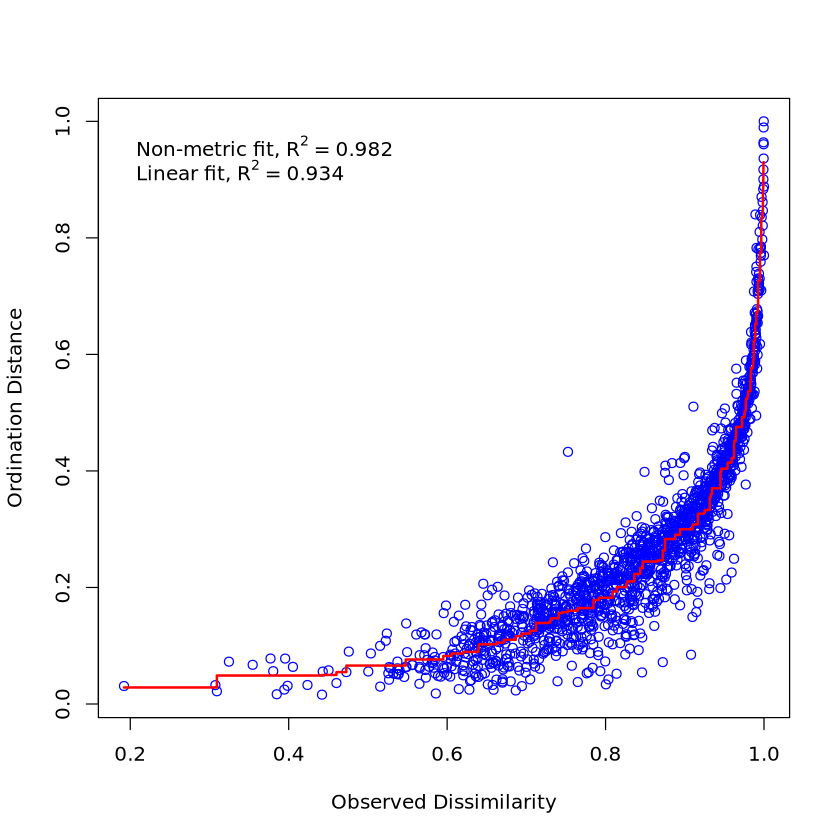

In [16]:
#created the distance matrix (bray curtis) first and then ran metaMDS
bray_dist<- vegdist(genes_filtered_reordered_t, "bray") 
bray<-as.matrix(bray_dist)
write.csv(bray, "bray_distance_matrix.csv")
set.seed(124)
MDS<- metaMDS(bray)
stressplot(MDS)

In [17]:
nmds_scores <- scores(MDS, choices=c(1,2))

In [18]:
write.csv(nmds_scores, file= "nmds_scores_all_genefamilies.csv")

In [19]:
#added a few columns to the scores csv for sample data
plot_scores <- read.csv("nmds_plot_all_genefamilies.csv", header=T)

In [20]:
options(repr.plot.width=15, repr.plot.height=15)

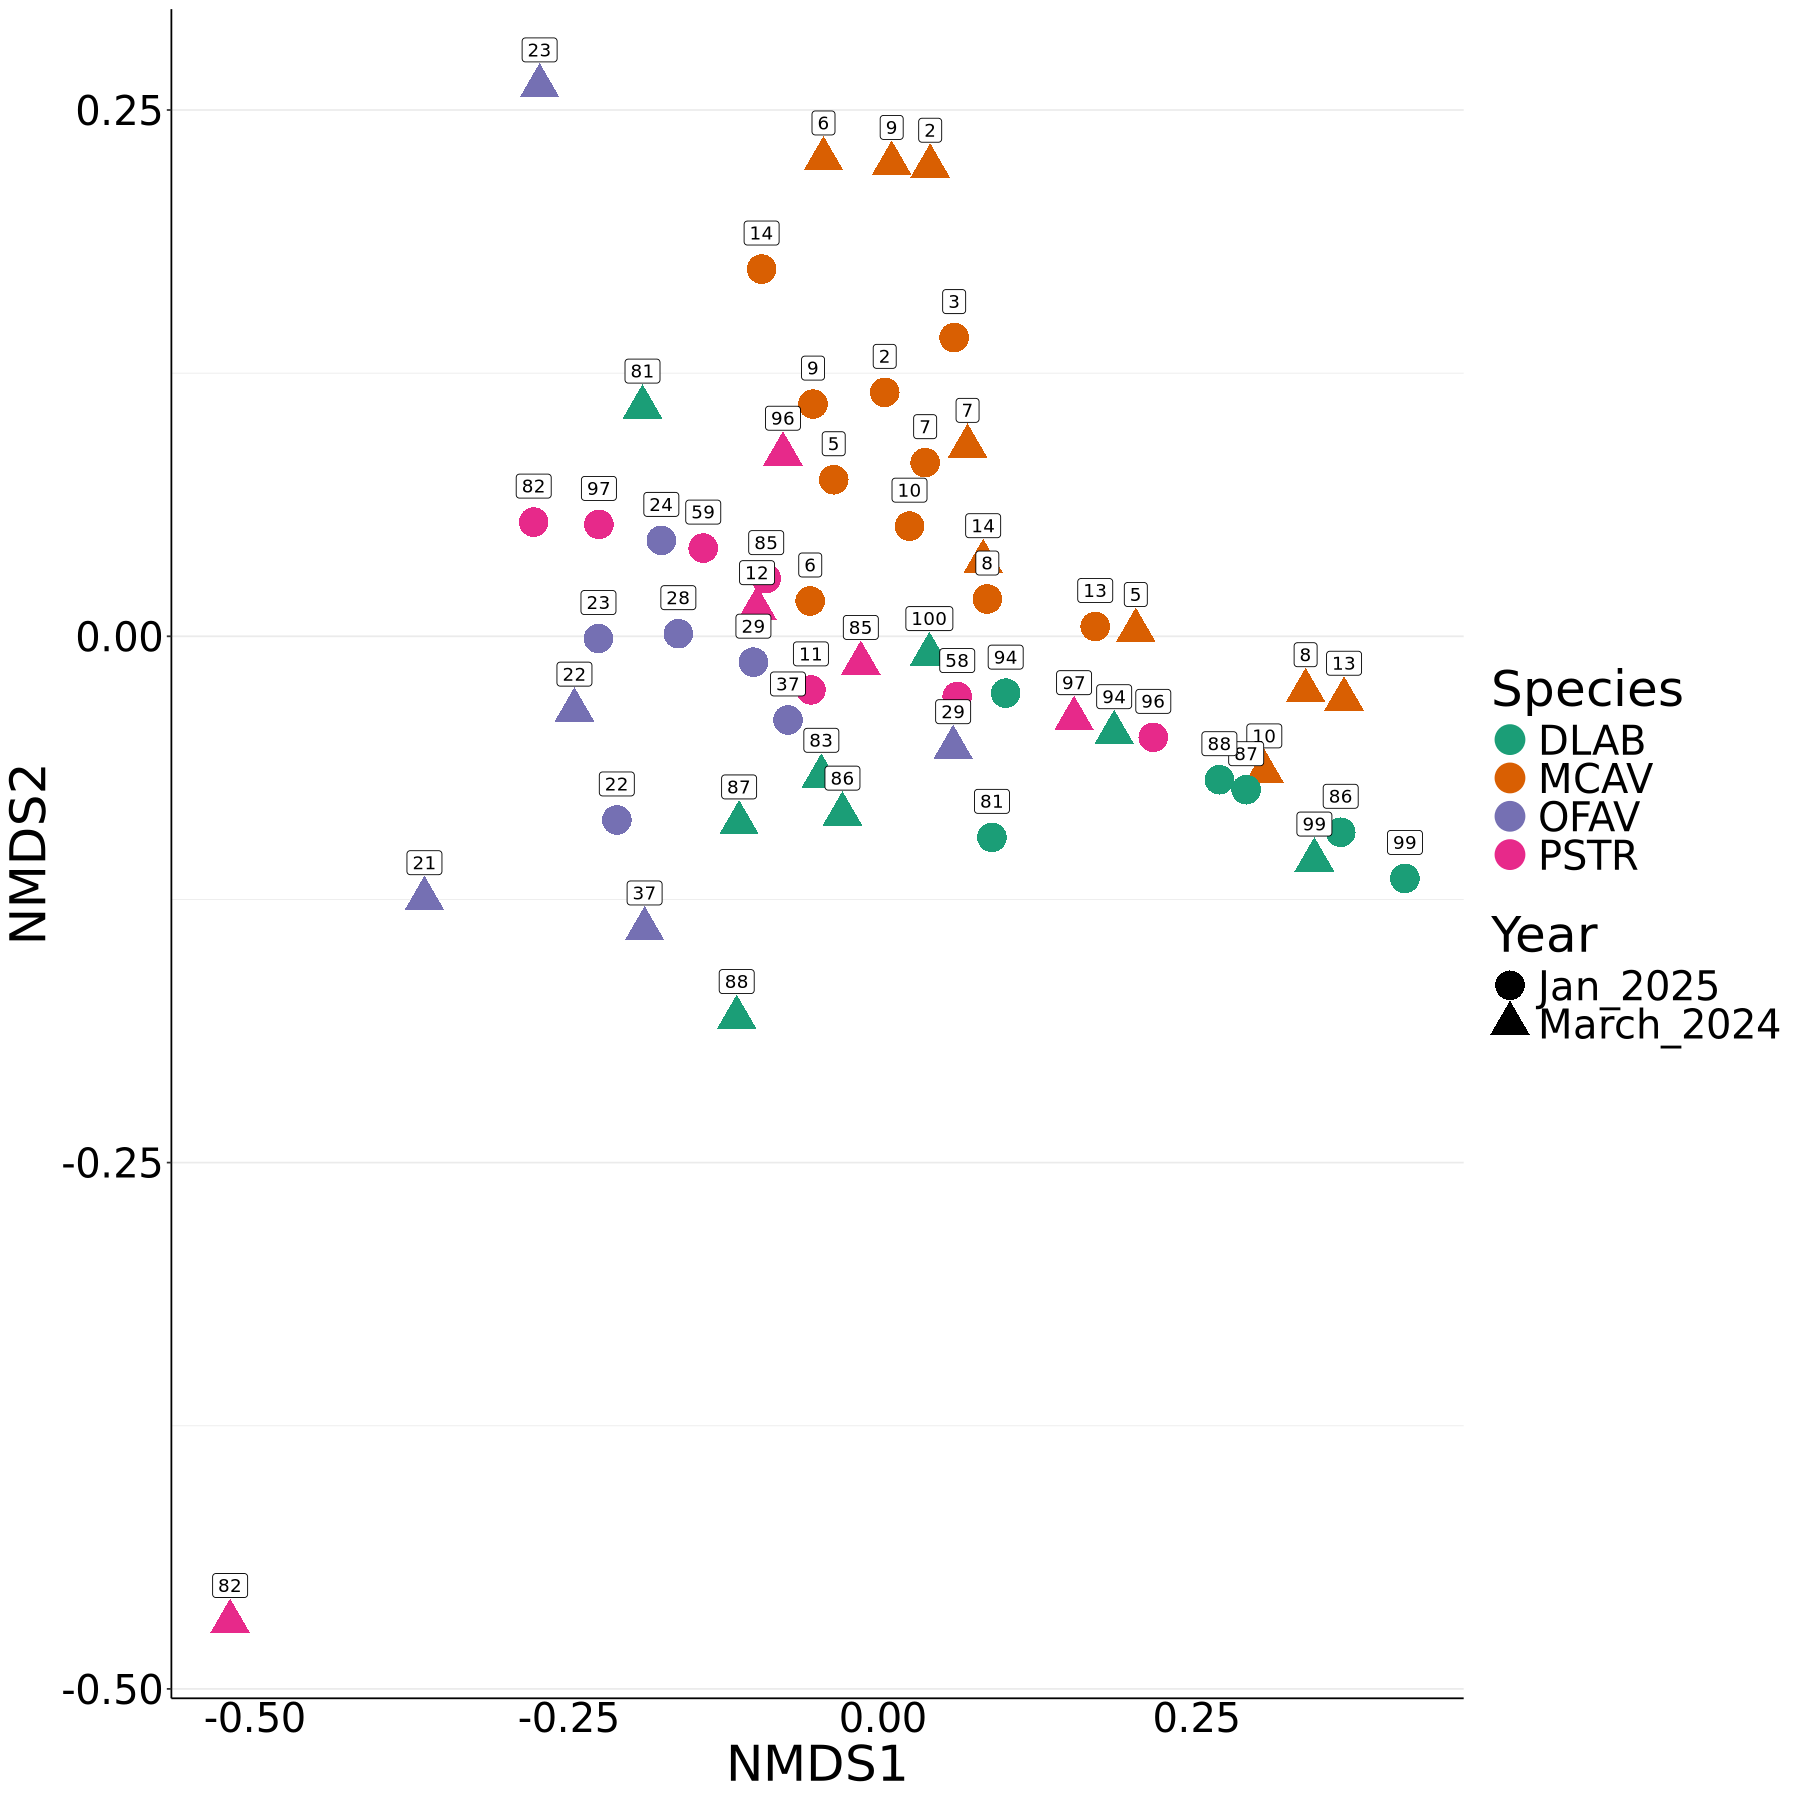

In [25]:
plot <- ggplot(data=plot_scores, aes(x=NMDS1,y=NMDS2, shape= Year, color = Species)) + 
  geom_point(size=8) + scale_color_brewer(palette = "Dark2") +
  #stat_ellipse(level = 0.95, type = "norm") +
  geom_label(aes(label = Tag), vjust = -1, color = "black") +
  xlab("NMDS1") + ylab ("NMDS2") +
  theme_bw() +
  theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 30))
    
plot

In [26]:
ggsave(filename = "bray_all_genes_nmds.png", plot = plot, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

sample 032024_COL_SAN_T5_144_PSTR_S9 is plotting weird (tag 82, triangle): not many genes identified, will remove and see how it affects clusters

In [32]:
plot_scores_filtered <- read.csv("nmds_plot_all_genefamilies.csv", header=T)
#remove 032024_COL_SAN_T5_144_PSTR_S9 just from nmds but I think I need to remove and recalculate distances, will do that below
plot_scores_filtered <- plot_scores_filtered[!grepl("032024_COL_SAN_T5_144_PSTR_S9", plot_scores_filtered$SampleID), ]

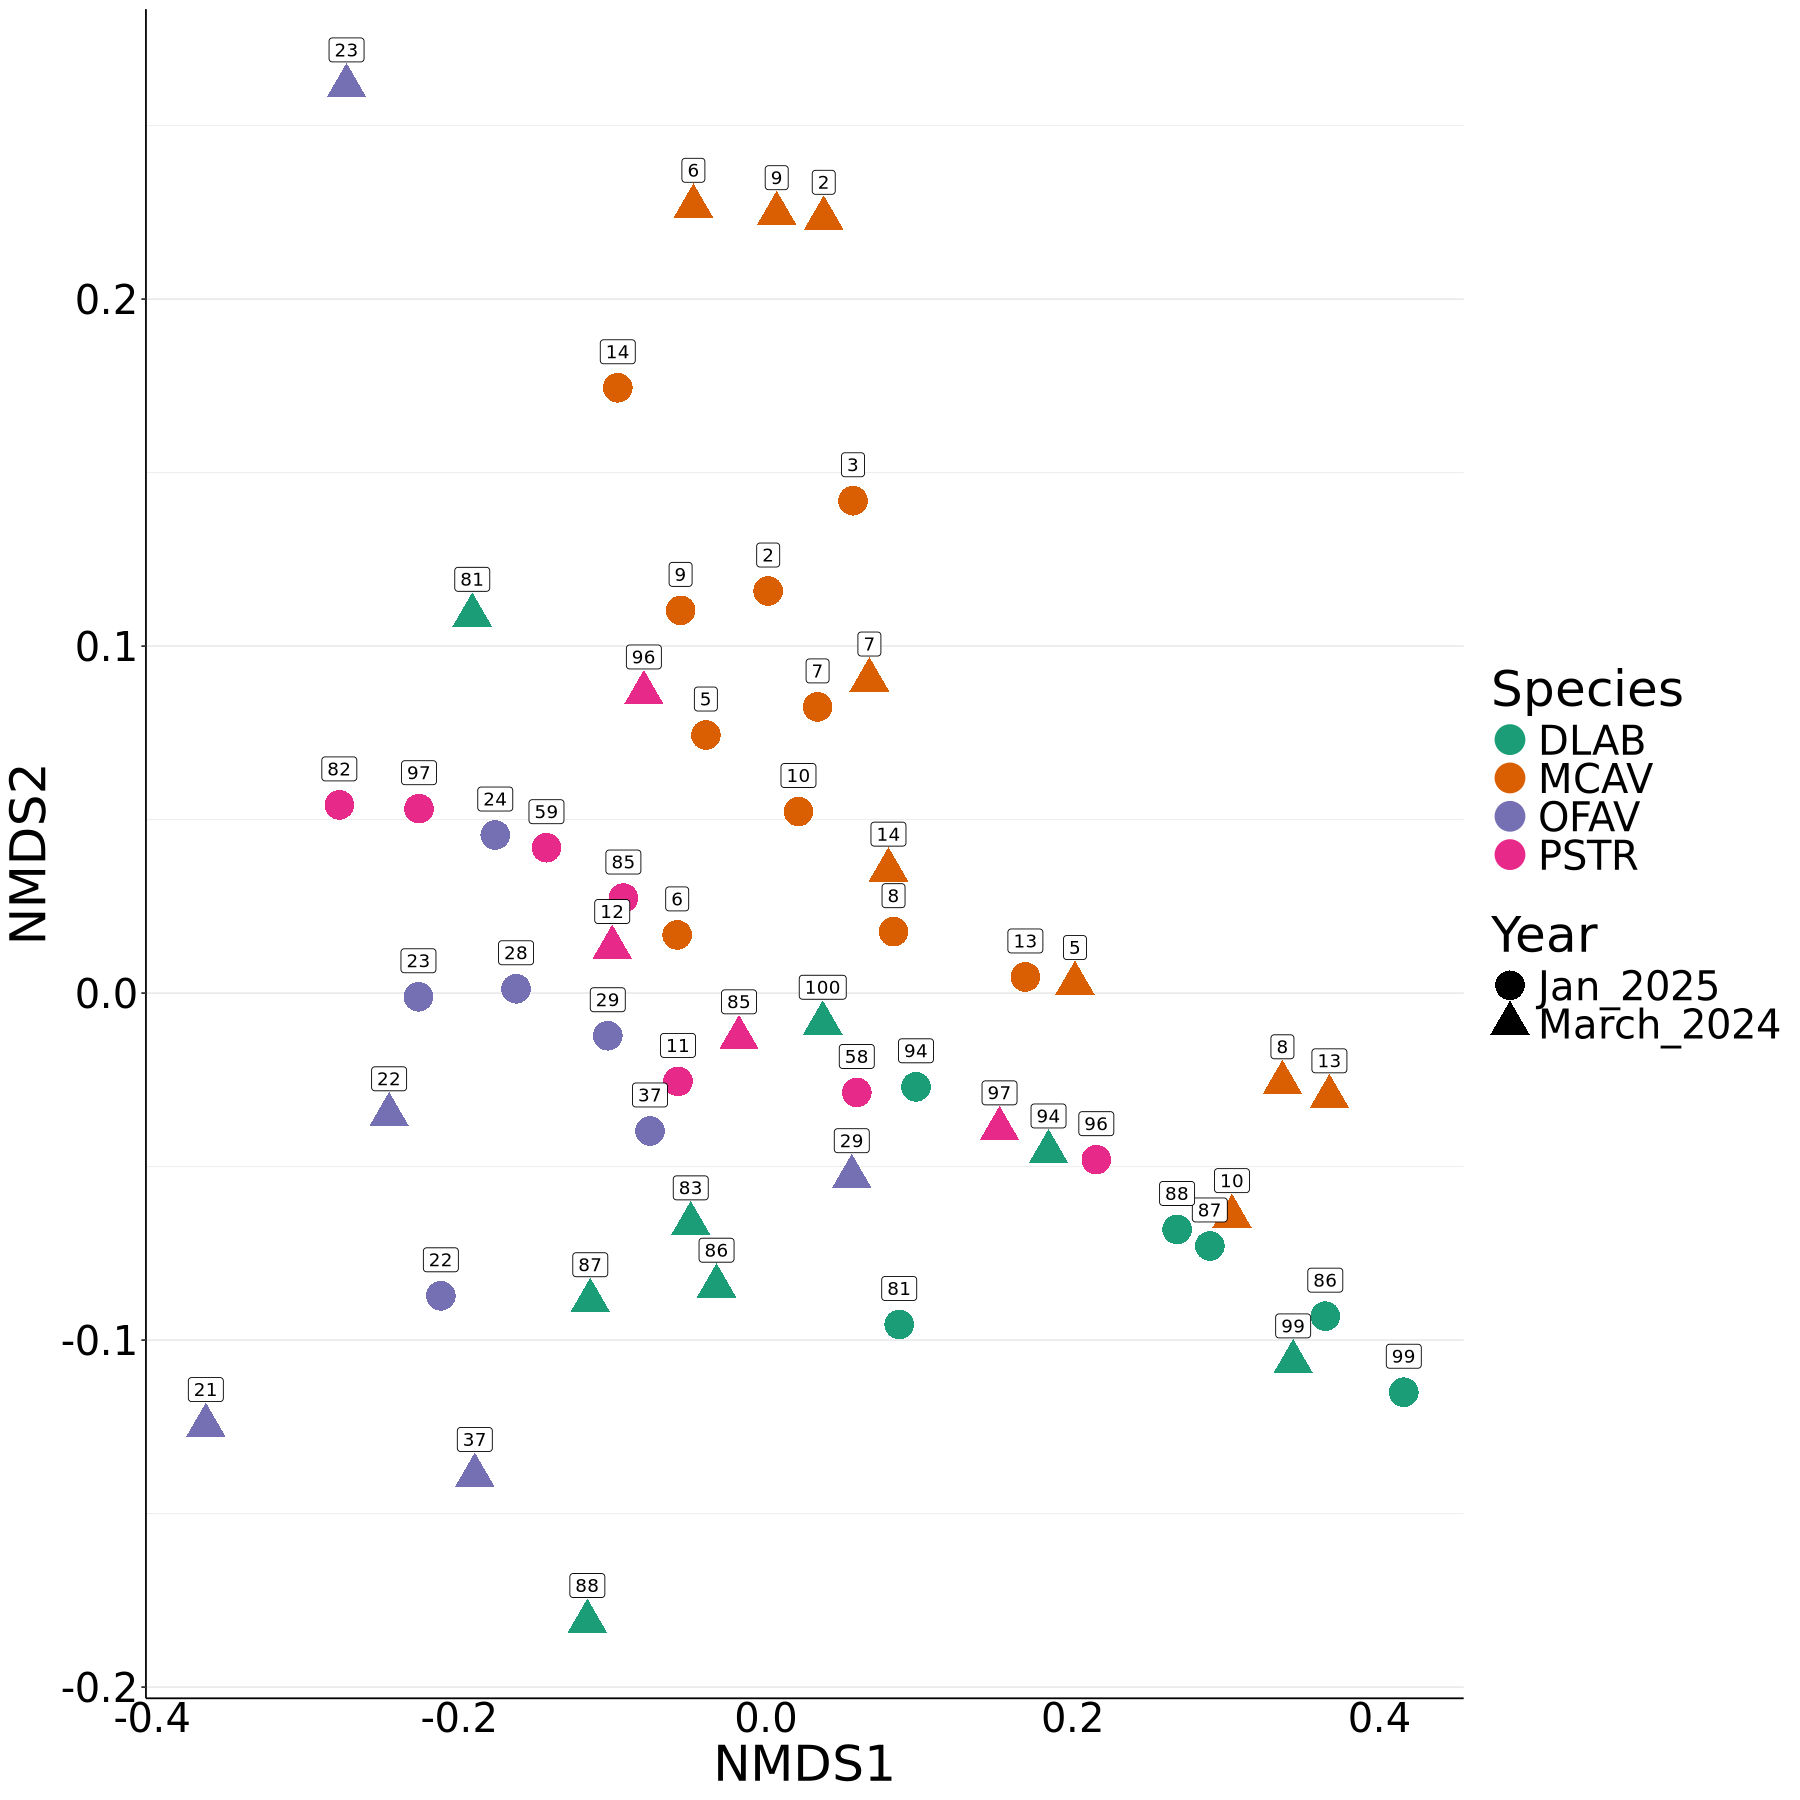

In [28]:
plot2 <- ggplot(data=plot_scores_filtered, aes(x=NMDS1,y=NMDS2, shape= Year, color = Species)) + 
  geom_point(size=8) + scale_color_brewer(palette = "Dark2") +
  #stat_ellipse(level = 0.95, type = "norm") +
  geom_label(aes(label = Tag), vjust = -1, color = "black") +
  xlab("NMDS1") + ylab ("NMDS2") +
  theme_bw() +
  theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 30))
    
plot2

### redo bray distances without sample: 032024_COL_SAN_T5_144_PSTR_S9

In [31]:
genes_filtered_reordered_minuspstrS9 <- select(genes_filtered_reordered, -"032024_COL_SAN_T5_144_PSTR_S9")
head(genes_filtered_reordered_minuspstrS9)

,Gene_Family,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.482772,0,0.000000,0,0,0.000000,0.000000
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,0,0,0,0,0,0,0,0,⋯,0,0,0.303034,0.000000,0,0.191229,0,0,1.218180,0.000000
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.000000,0.000000
12,1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.328109,0.000000
14,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.303235,0.000000
16,1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,2.100650,0,0.000000,0,0,0.000000,0.278843


In [13]:
# make the index the gene_family
row.names(genes_filtered_reordered_minuspstrS9) <- genes_filtered_reordered_minuspstrS9$Gene_Family
genes_filtered_reordered_minuspstrS9$Gene_Family <- NULL
head(genes_filtered_reordered_minuspstrS9)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.482772,0,0.000000,0,0,0.000000,0.000000
1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.303034,0.000000,0,0.191229,0,0,1.218180,0.000000
1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.000000,0.000000
1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.328109,0.000000
1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.303235,0.000000
1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,2.100650,0,0.000000,0,0,0.000000,0.278843


In [14]:
#transpose - want samples as rows
genes_filtered_reordered_minuspstrS9_t <- t(genes_filtered_reordered_minuspstrS9)
head(genes_filtered_reordered_minuspstrS9_t)

,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],1.1.1.271-RXN: (expasy) GDP-L-fucose synthase [1.1.1.271],"1.1.1.274-RXN: (expasy) 2,5-didehydrogluconate reductase (2-dehydro-D-gluconate-forming) [1.1.1.274]",1.1.1.291-RXN: (expasy) 2-hydroxymethylglutarate dehydrogenase [1.1.1.291],"1.1.1.292-RXN: (expasy) 1,5-anhydro-D-fructose reductase (1,5-anhydro-D-mannitol-forming) [1.1.1.292]",⋯,UROGENDECARBOX-RXN: (expasy) Uroporphyrinogen decarboxylase [4.1.1.37],UROGENIIISYN-RXN: (expasy) Uroporphyrinogen-III synthase [4.2.1.75],URPHOS-RXN: (expasy) AMBIGUOUS [2.4.2.2; 2.4.2.3],VALINE--TRNA-LIGASE-RXN: (expasy) Valine--tRNA ligase [6.1.1.9],VALINE-PYRUVATE-AMINOTRANSFER-RXN: (expasy) Valine--pyruvate transaminase [2.6.1.66],XANPRIBOSYLTRAN-RXN: (expasy) Xanthine phosphoribosyltransferase [2.4.2.22],XANTHOSINEPHOSPHORY-RXN: (expasy) Purine-nucleoside phosphorylase [2.4.2.1],XMPXAN-RXN: (expasy) 5'-nucleotidase [3.1.3.5],XYLISOM-RXN: (expasy) Xylose isomerase [5.3.1.5],XYLULOKIN-RXN: (expasy) Xylulokinase [2.7.1.17]
032024_COL_SAN_T5_139_OFAV_S17,0,0,0,0,0,0,0,1.03453,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
032024_COL_SAN_T5_140_OFAV_S18c,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
032024_COL_SAN_T5_141_OFAV_S19,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
032024_COL_SAN_T5_166_OFAV_S20,0,0,0,0,0,0,0,0.00000,0,0,⋯,1.969886,0,0,0.000000,0,0,0,0,0.000000,0.694876
032024_COL_SAN_T5_167_OFAV_S21,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
012025_COL_SAN_T5_568_OFAV_S1,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.643074,0,0,0.284085,0,0,0,0,0.372796,0.000000


In [15]:
#convert to matrix
genes_filtered_reordered_minuspstrS9_t=as.matrix(genes_filtered_reordered_minuspstrS9_t)
head(genes_filtered_reordered_minuspstrS9_t)

,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],1.1.1.271-RXN: (expasy) GDP-L-fucose synthase [1.1.1.271],"1.1.1.274-RXN: (expasy) 2,5-didehydrogluconate reductase (2-dehydro-D-gluconate-forming) [1.1.1.274]",1.1.1.291-RXN: (expasy) 2-hydroxymethylglutarate dehydrogenase [1.1.1.291],"1.1.1.292-RXN: (expasy) 1,5-anhydro-D-fructose reductase (1,5-anhydro-D-mannitol-forming) [1.1.1.292]",⋯,UROGENDECARBOX-RXN: (expasy) Uroporphyrinogen decarboxylase [4.1.1.37],UROGENIIISYN-RXN: (expasy) Uroporphyrinogen-III synthase [4.2.1.75],URPHOS-RXN: (expasy) AMBIGUOUS [2.4.2.2; 2.4.2.3],VALINE--TRNA-LIGASE-RXN: (expasy) Valine--tRNA ligase [6.1.1.9],VALINE-PYRUVATE-AMINOTRANSFER-RXN: (expasy) Valine--pyruvate transaminase [2.6.1.66],XANPRIBOSYLTRAN-RXN: (expasy) Xanthine phosphoribosyltransferase [2.4.2.22],XANTHOSINEPHOSPHORY-RXN: (expasy) Purine-nucleoside phosphorylase [2.4.2.1],XMPXAN-RXN: (expasy) 5'-nucleotidase [3.1.3.5],XYLISOM-RXN: (expasy) Xylose isomerase [5.3.1.5],XYLULOKIN-RXN: (expasy) Xylulokinase [2.7.1.17]
032024_COL_SAN_T5_139_OFAV_S17,0,0,0,0,0,0,0,1.03453,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
032024_COL_SAN_T5_140_OFAV_S18c,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
032024_COL_SAN_T5_141_OFAV_S19,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
032024_COL_SAN_T5_166_OFAV_S20,0,0,0,0,0,0,0,0.00000,0,0,⋯,1.969886,0,0,0.000000,0,0,0,0,0.000000,0.694876
032024_COL_SAN_T5_167_OFAV_S21,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.000000,0,0,0.000000,0,0,0,0,0.000000,0.000000
012025_COL_SAN_T5_568_OFAV_S1,0,0,0,0,0,0,0,0.00000,0,0,⋯,0.643074,0,0,0.284085,0,0,0,0,0.372796,0.000000


Run 0 stress 0.143146 
Run 1 stress 0.158897 
Run 2 stress 0.1511041 
Run 3 stress 0.1445477 
Run 4 stress 0.1535342 
Run 5 stress 0.1439905 
Run 6 stress 0.1475182 
Run 7 stress 0.1551391 
Run 8 stress 0.1549877 
Run 9 stress 0.1431459 
... New best solution
... Procrustes: rmse 5.167364e-05  max resid 0.0001946647 
... Similar to previous best
Run 10 stress 0.151922 
Run 11 stress 0.1457569 
Run 12 stress 0.1441505 
Run 13 stress 0.1676963 
Run 14 stress 0.1528273 
Run 15 stress 0.1564547 
Run 16 stress 0.1431461 
... Procrustes: rmse 0.0001565903  max resid 0.0009430198 
... Similar to previous best
Run 17 stress 0.144738 
Run 18 stress 0.1616541 
Run 19 stress 0.1529417 
Run 20 stress 0.1542317 
*** Best solution repeated 2 times


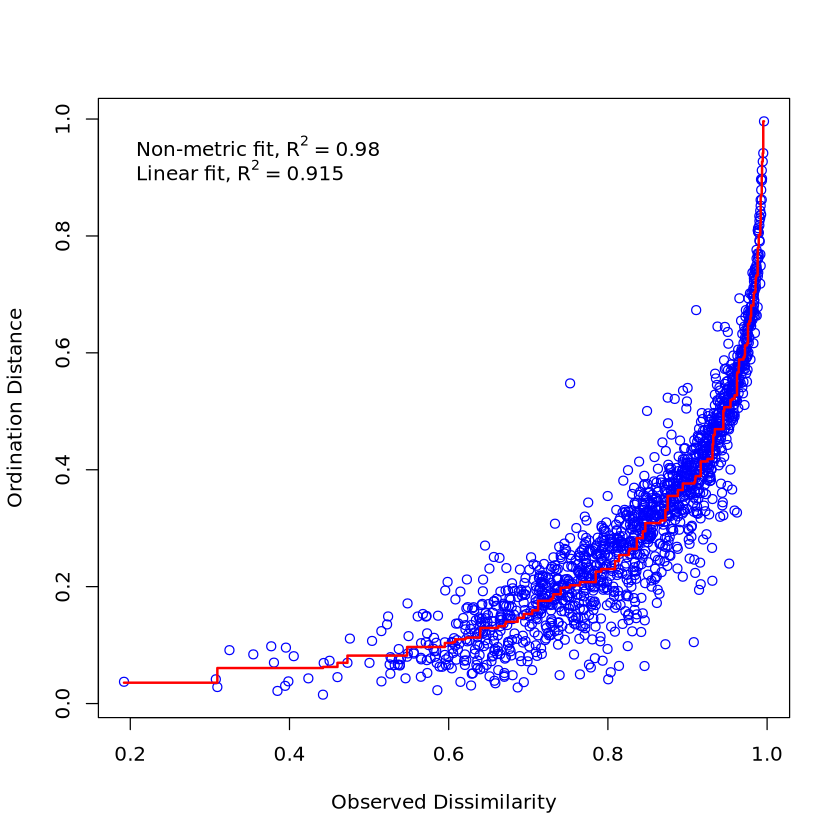

In [17]:
#created the distance matrix (bray curtis) first and then ran metaMDS
bray_dist_filtered<- vegdist(genes_filtered_reordered_minuspstrS9_t, "bray") 
bray_f<-as.matrix(bray_dist_filtered)
write.csv(bray_f, "bray_distance_filtered_matrix.csv")
set.seed(125)
MDS_f<- metaMDS(bray_f)
stressplot(MDS_f)

In [18]:
nmds_scores_f <- scores(MDS_f, choices=c(1,2))

In [19]:
write.csv(nmds_scores_f, file= "nmds_scores_filtered_all_genefamilies.csv")

In [25]:
#added a few columns to the scores csv for sample data
plot_scores_f <- read.csv("nmds_plot_filtered_all_genefamilies.csv", header=T)

In [23]:
options(repr.plot.width=15, repr.plot.height=15)

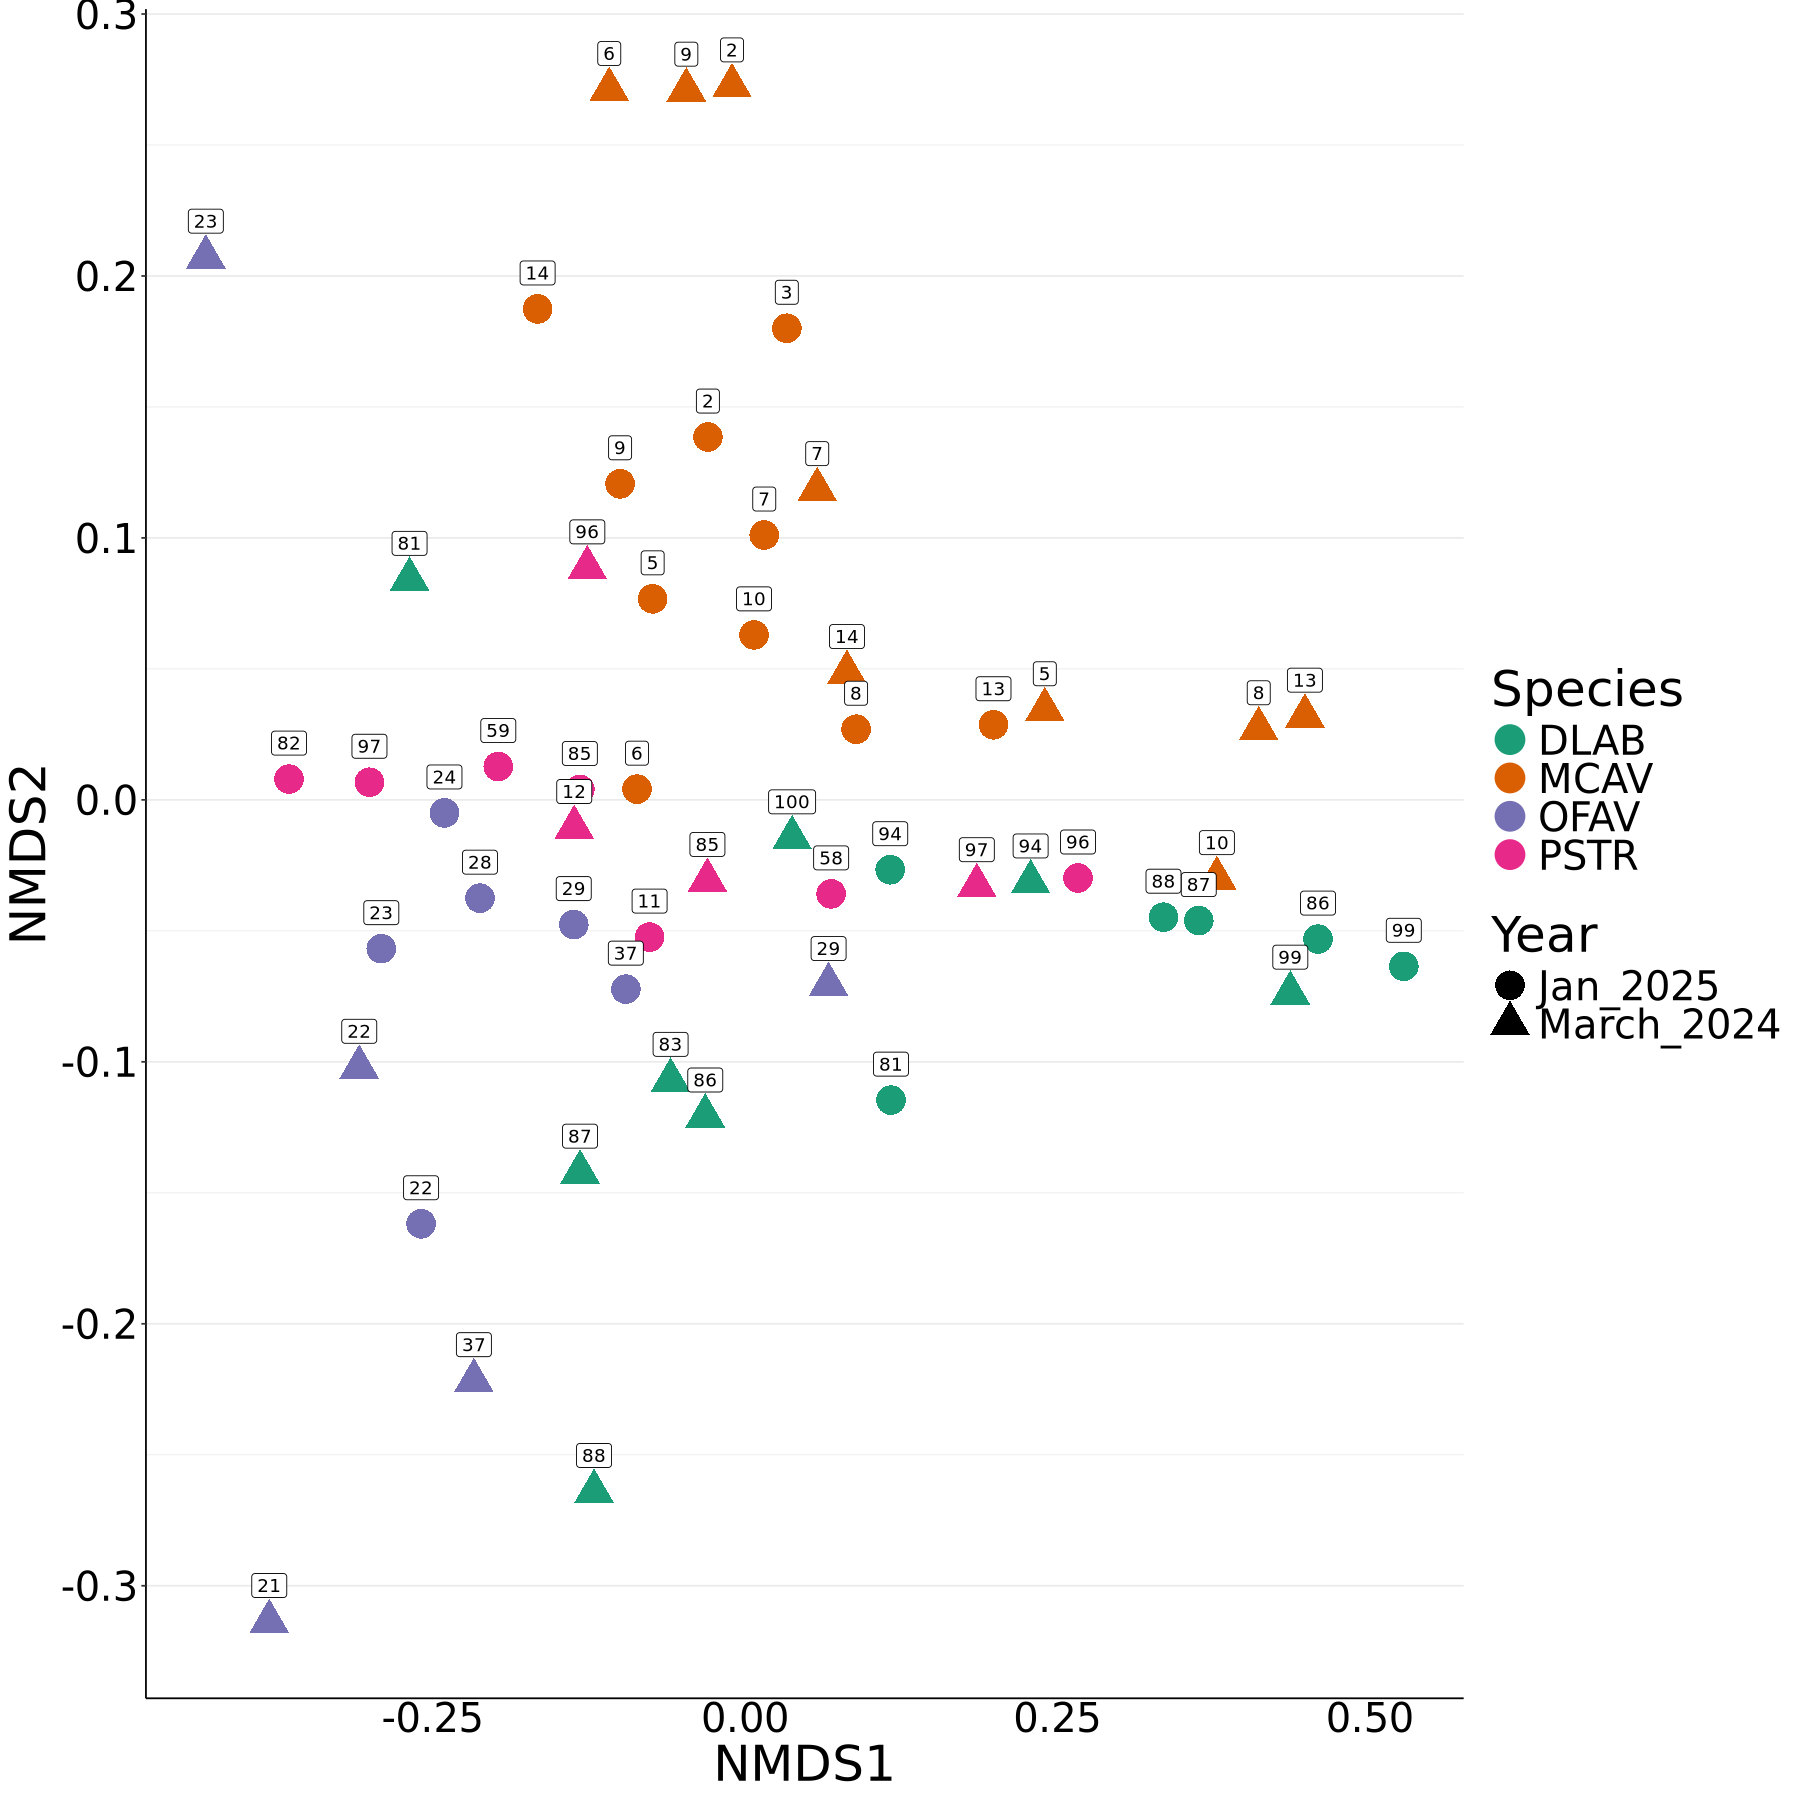

In [26]:
plot3 <- ggplot(data=plot_scores_f, aes(x=NMDS1,y=NMDS2, shape= Year, color = Species)) + 
  geom_point(size=8) + scale_color_brewer(palette = "Dark2") +
  #stat_ellipse(level = 0.95, type = "norm") +
  geom_label(aes(label = Tag), vjust = -1, color = "black") +
  xlab("NMDS1") + ylab ("NMDS2") +
  theme_bw() +
  theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 30))
    
plot3

In [29]:
ggsave(filename = "bray_filtered_all_genes_nmds.png", plot = plot3, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

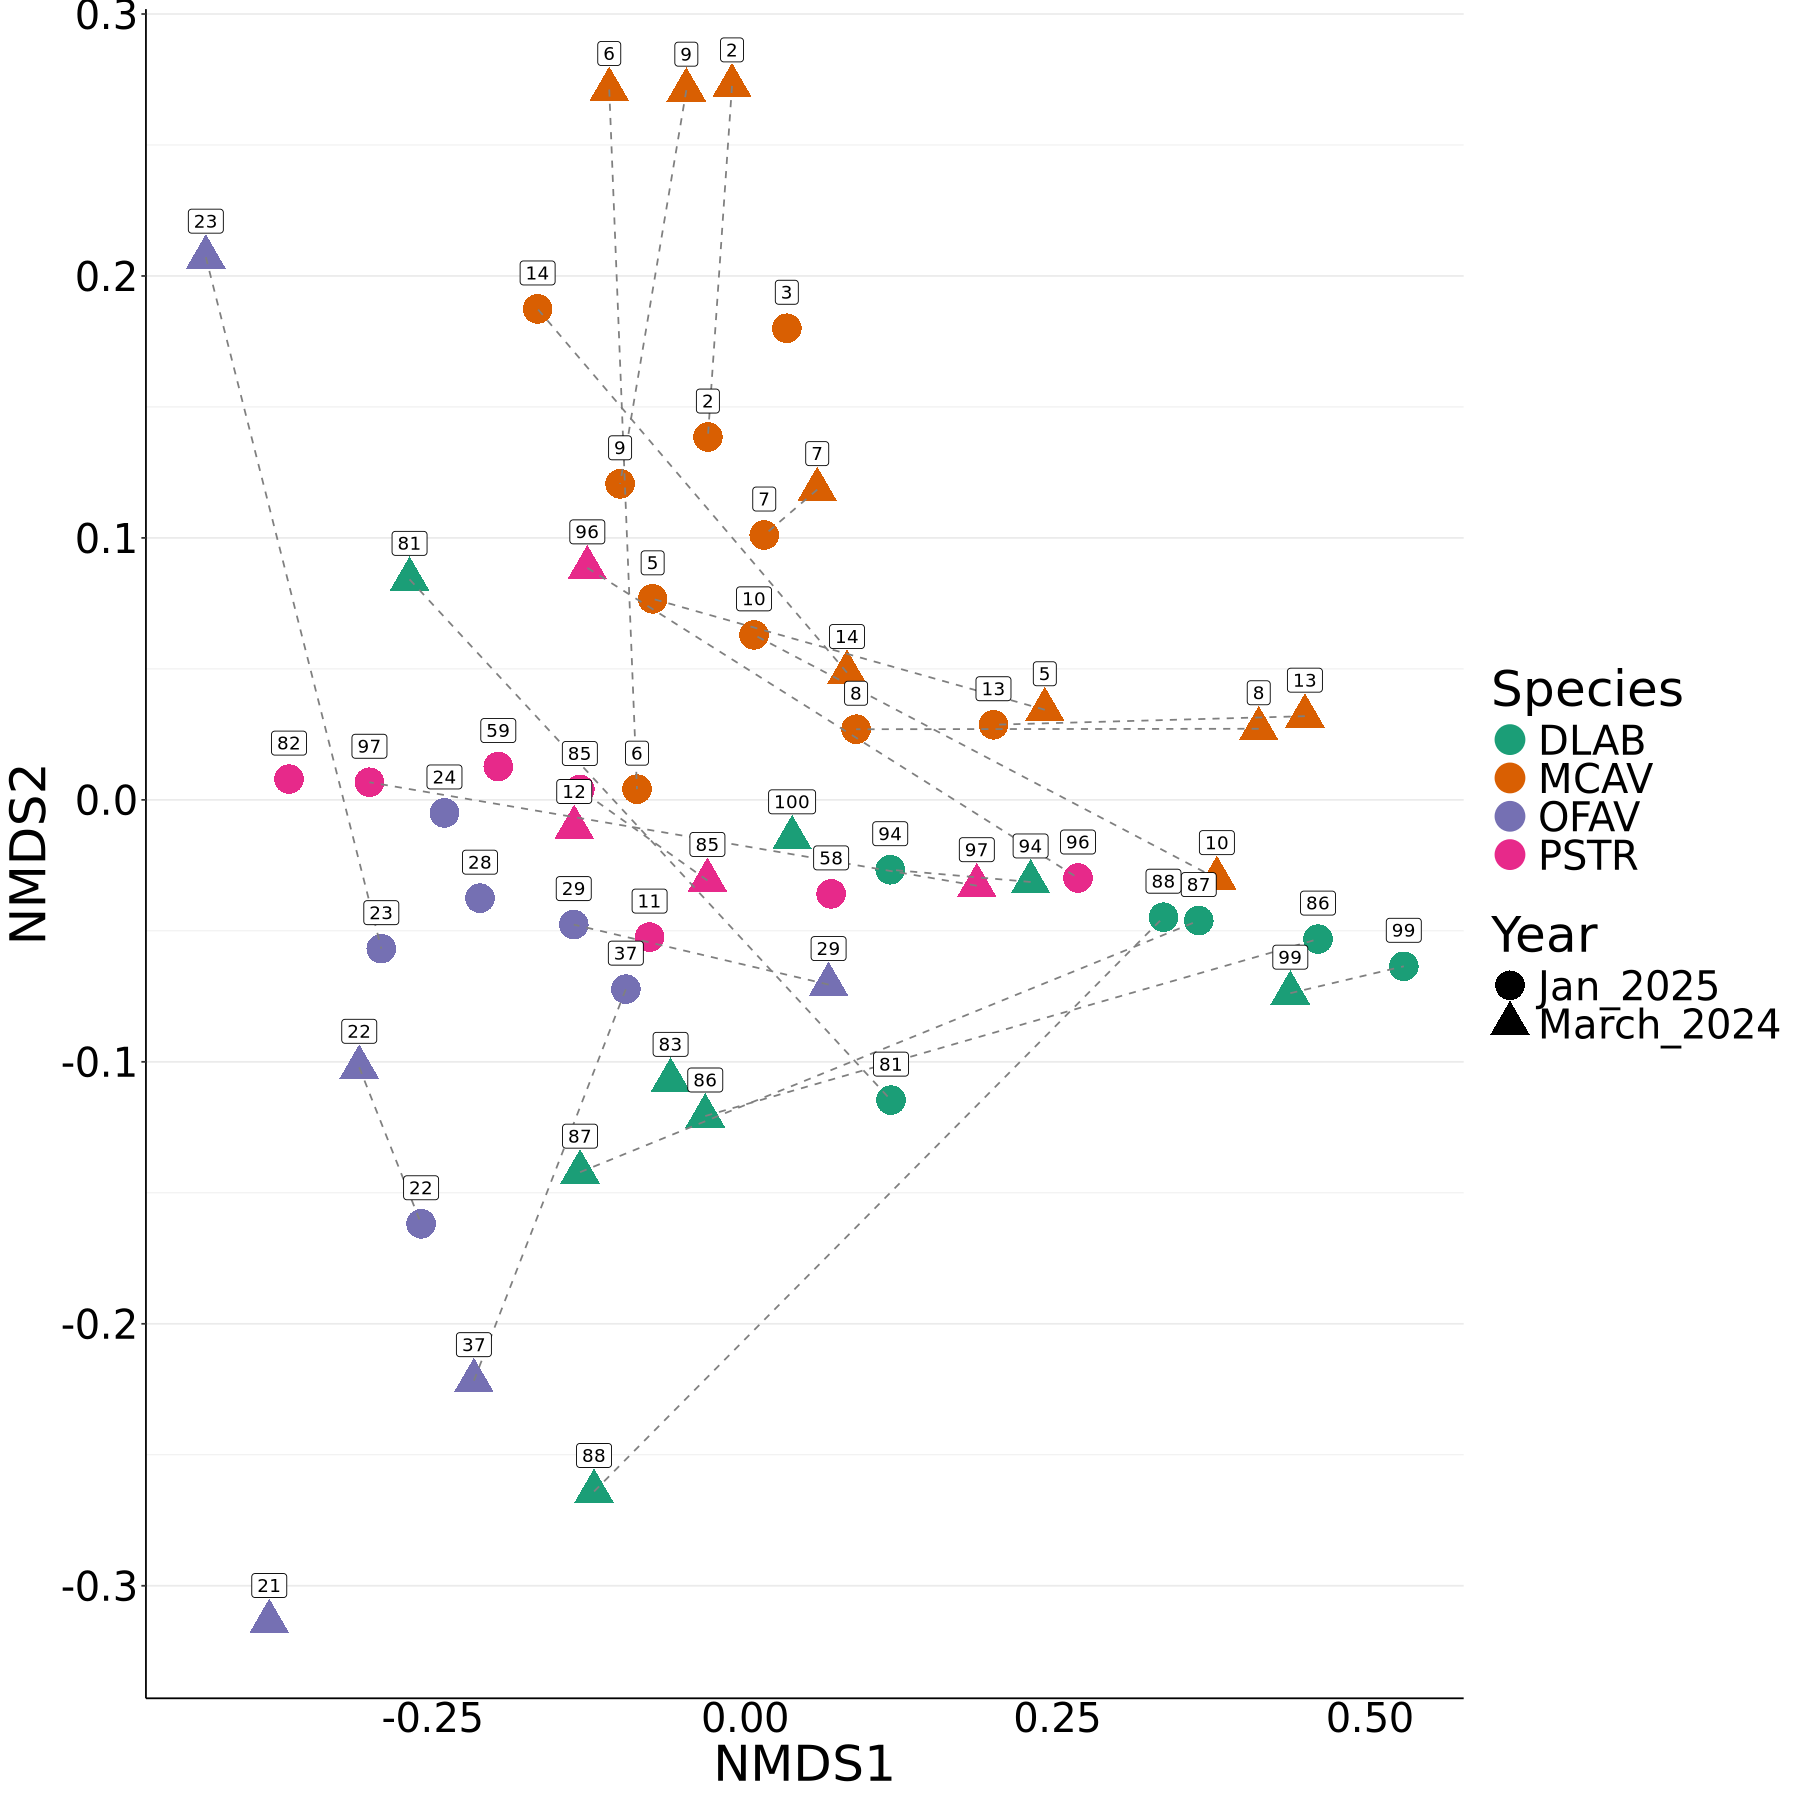

In [27]:
plot4 <- ggplot(data=plot_scores_f, aes(x=NMDS1,y=NMDS2, shape= Year, color = Species)) + 
  geom_point(size=8) + scale_color_brewer(palette = "Dark2") +
  geom_path(aes(group = Tag), color = "gray50", linetype = "dashed") +
  #stat_ellipse(level = 0.95, type = "norm") +
  geom_label(aes(label = Tag), vjust = -1, color = "black") +
  xlab("NMDS1") + ylab ("NMDS2") +
  theme_bw() +
  theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 30))
    
plot4

In [28]:
ggsave(filename = "bray_filtered_paths_all_genes_nmds.png", plot = plot4, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

#### Different distance matrices

Run 0 stress 0.1331913 
Run 1 stress 0.1511354 
Run 2 stress 0.1426304 
Run 3 stress 0.1461097 
Run 4 stress 0.1299456 
... New best solution
... Procrustes: rmse 0.04546608  max resid 0.2313144 
Run 5 stress 0.1450156 
Run 6 stress 0.1560936 
Run 7 stress 0.1542751 
Run 8 stress 0.1331915 
Run 9 stress 0.1337994 
Run 10 stress 0.1478534 
Run 11 stress 0.1299456 
... Procrustes: rmse 0.0002421673  max resid 0.001196572 
... Similar to previous best
Run 12 stress 0.1463943 
Run 13 stress 0.1280548 
... New best solution
... Procrustes: rmse 0.03010925  max resid 0.2004653 
Run 14 stress 0.1300268 
Run 15 stress 0.1339189 
Run 16 stress 0.1280548 
... Procrustes: rmse 0.0003002998  max resid 0.001278705 
... Similar to previous best
Run 17 stress 0.1464691 
Run 18 stress 0.1514794 
Run 19 stress 0.1280555 
... Procrustes: rmse 0.0005115402  max resid 0.002327813 
... Similar to previous best
Run 20 stress 0.1419706 
*** Best solution repeated 2 times


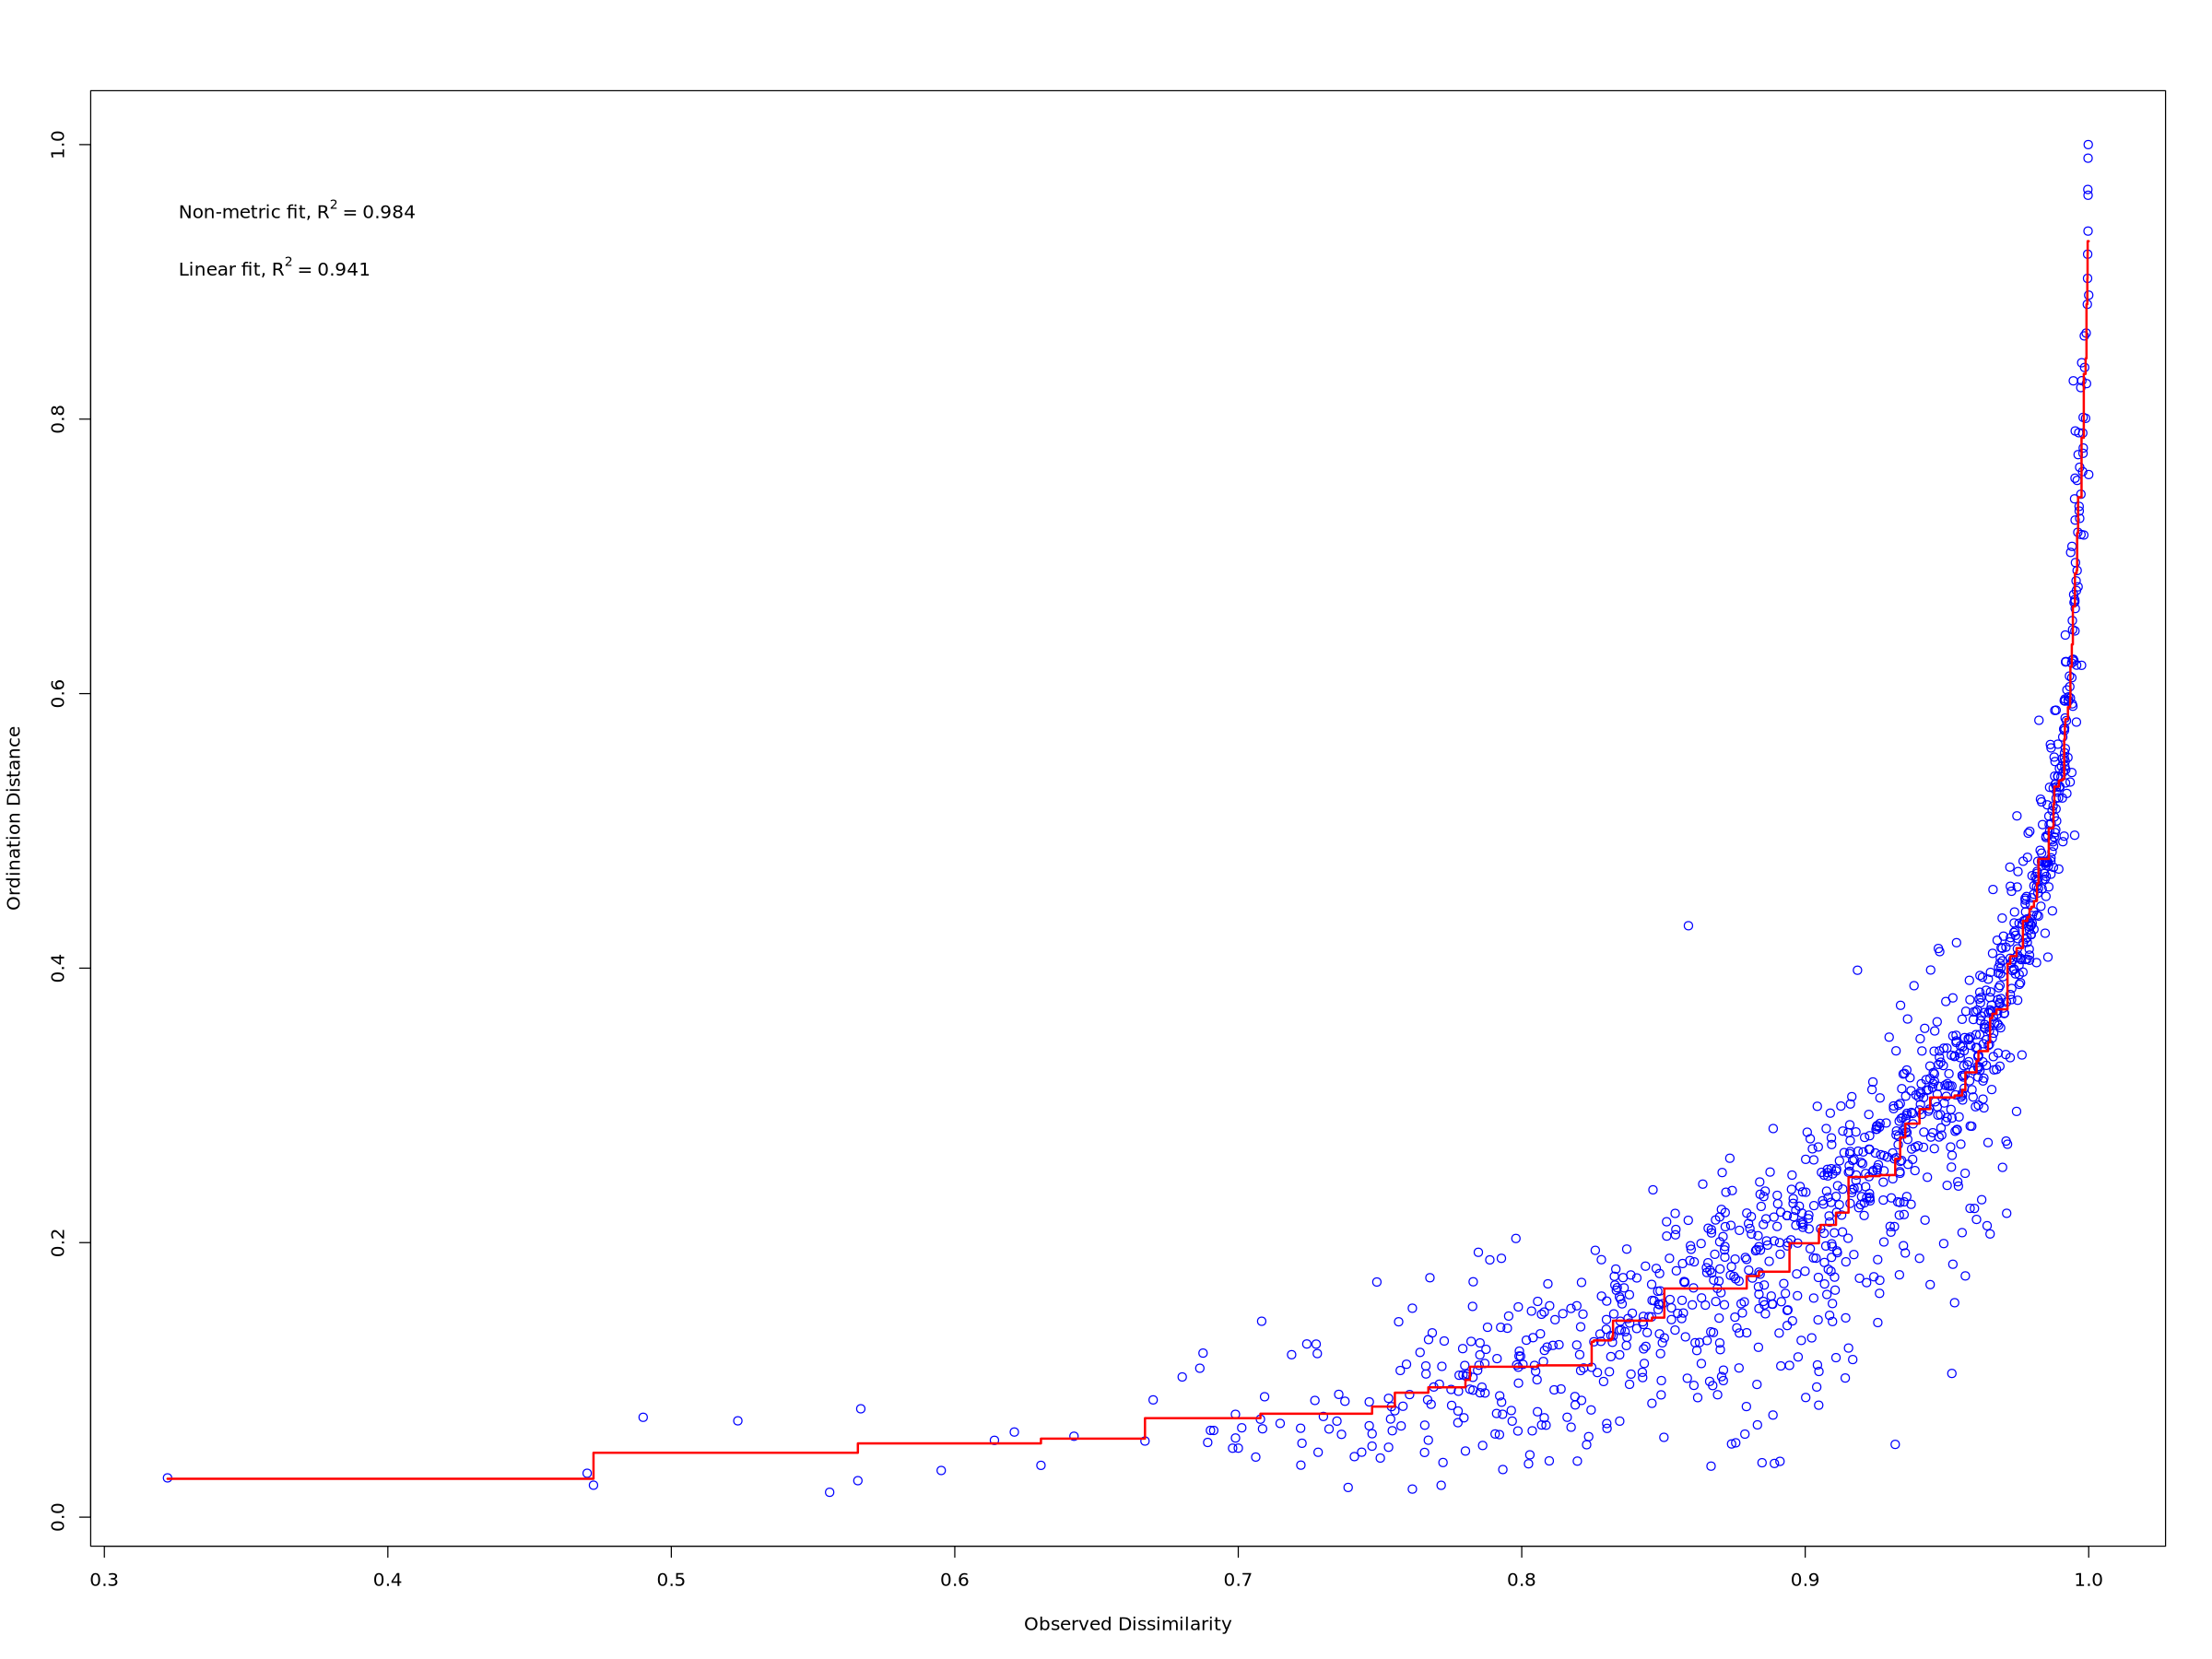

In [35]:
#let's try a different distance matrix
jaccard_dist<- vegdist(genes_filtered_reordered_t, "jaccard") 
jaccard<-as.matrix(jaccard_dist)
write.csv(bray, "jaccard_distance_matrix.csv")
set.seed(124)
MDS_jac<- metaMDS(jaccard)
stressplot(MDS_jac)

In [30]:
nmds_scores_j <- scores(MDS_jac, choices=c(1,2))

In [31]:
write.csv(nmds_scores_j, file= "nmds_scores_jaccard_all_but_0125_pstr_genefamilies.csv")

In [32]:
plot_scores_j <- read.csv("nmds_plot_jaccard_all_but_0125_pstr_genefamilies.csv", header=T)

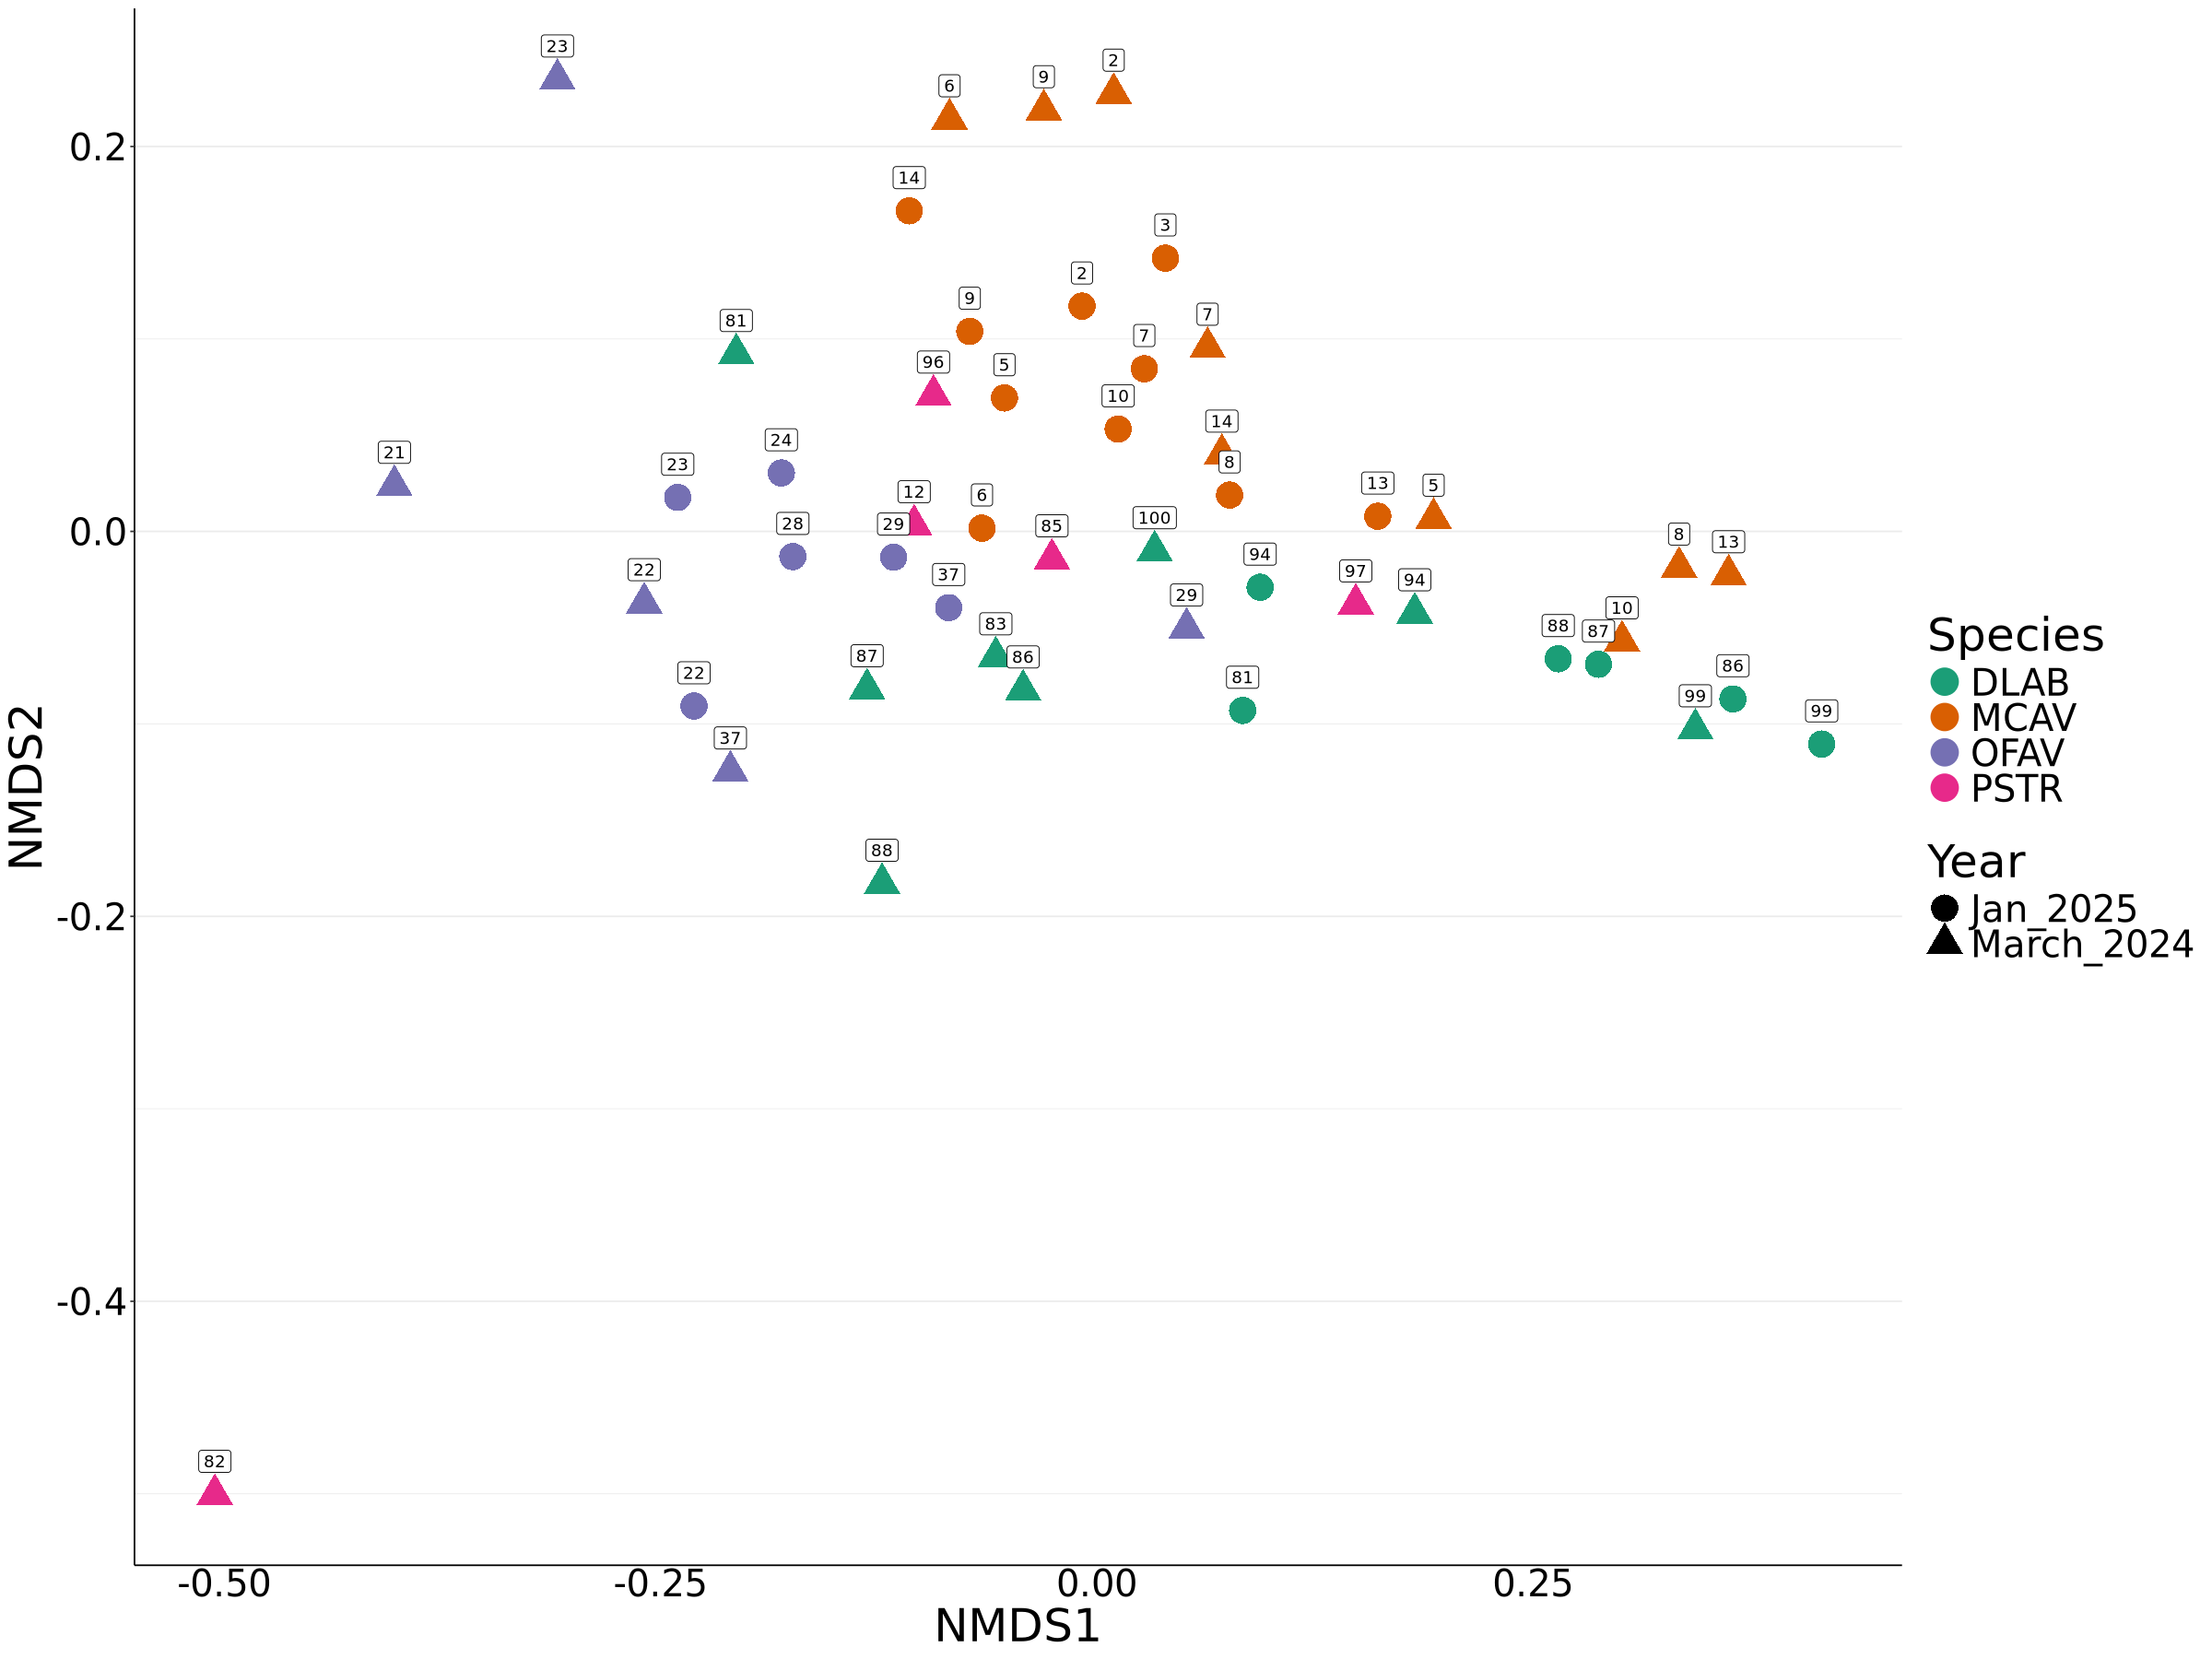

In [33]:
plot2 <- ggplot(data=plot_scores_j, aes(x=NMDS1,y=NMDS2, shape= Year, color = Species)) + 
  geom_point(size=8) + scale_color_brewer(palette = "Dark2") +
  geom_label(aes(label = Tag), vjust = -1, color = "black") +
  xlab("NMDS1") + ylab ("NMDS2") +
  theme_bw() +
  theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 30))
    
plot2

In [ ]:
try another - mayve aitchison but would have to transform the data...

### Heatmap of genes/pathways

In [4]:
#install.packages("pheatmap")

In [3]:
if (!require("remotes")){
    install.packages("remotes")
}
remotes::install_github("gesistsa/rio")

Loading required package: remotes




cpp11      (0.5.3   -> 0.5.5 ) [CRAN]
magrittr   (2.0.4   -> 2.0.5 ) [CRAN]
vctrs      (0.7.1   -> 0.7.3 ) [CRAN]
rlang      (1.1.7   -> 1.2.0 ) [CRAN]
glue       (1.8.0   -> 1.8.1 ) [CRAN]
cli        (3.6.5   -> 3.6.6 ) [CRAN]
bit64      (4.6.0-1 -> 4.8.2 ) [CRAN]
vroom      (1.6.7   -> 1.7.1 ) [CRAN]
clipr      (0.8.0   -> 0.8.1 ) [CRAN]
writexl    (NA      -> 1.5.4 ) [CRAN]
readxl     (1.4.5   -> 1.5.0 ) [CRAN]
data.table (1.17.8  -> 1.18.4) [CRAN]
curl       (7.0.0   -> 7.1.0 ) [CRAN]


Installing 13 packages: cpp11, magrittr, vctrs, rlang, glue, cli, bit64, vroom, clipr, writexl, readxl, data.table, curl

Warning message in i.p(...):
“installation of package ‘writexl’ had non-zero exit status”
Warning message in i.p(...):
“installation of package ‘data.table’ had non-zero exit status”
Warning message in i.p(...):
“installation of package ‘curl’ had non-zero exit status”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Running `R CMD build`...



* checking for file ‘/tmp/Rtmpi8U6FN/remotes3cffa14982cfcc/gesistsa-rio-309076b/DESCRIPTION’ ... OK
* preparing ‘rio’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* looking to see if a ‘data/datalist’ file should be added
* building ‘rio_1.3.0.tar.gz’


Warning message in i.p(...):
“installation of package ‘/tmp/Rtmpi8U6FN/file3cffa11774e40/rio_1.3.0.tar.gz’ had non-zero exit status”


In [17]:
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install("apeglm")

Bioconductor version '3.20' is out-of-date; the current release version '3.23'
  is available with R version '4.6'; see https://bioconductor.org/install

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.20 (BiocManager 1.30.27), R 4.4.3 (2025-02-28)

Installing package(s) 'apeglm'

also installing the dependencies ‘numDeriv’, ‘bdsmatrix’, ‘mvtnorm’, ‘coda’, ‘bbmle’, ‘emdbook’, ‘RcppEigen’, ‘RcppNumerical’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Old packages: 'ade4', 'backports', 'Biostrings', 'broom', 'bslib', 'curl',
  'data.table', 'DBI', 'dplyr', 'ellipsis', 'fs', 'GenomeInfoDb', 'ggplot2',
  'ggrepel', 'highr', 'igraph', 'IRanges', 'Matrix', 'nlme', 'openssl',
  'processx', 'ps', 'purrr', 'ragg', 'Rcpp', 'RcppArmadillo', 'rhdf5',
  'rhdf5filters', 'rmarkdown', 'S7', 'system

In [20]:
install.packages("ggpicrust2")

also installing the dependencies ‘tweenr’, ‘polyclip’, ‘gridExtra’, ‘ggfun’, ‘yulab.utils’, ‘gridGraphics’, ‘ggforce’, ‘viridis’, ‘graphlayouts’, ‘aplot’, ‘ggh4x’, ‘ggprism’, ‘patchwork’, ‘ggplotify’, ‘tidygraph’, ‘ggraph’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [21]:
library(tidyverse)
library(magrittr)
library(pheatmap)
library(RColorBrewer)
#library(rio)
library(DESeq2)
library(ggplot2)
library(apeglm)
library(ggpicrust2)
library(ggh4x)
library(dplyr)
library(tidyr)
library(tibble)

Loading required package: ggpicrust2

To cite ggpicrust2 in publications use:

Chen Yang, Jiahao Mai, Xuan Cao, Aaron Burberry, Fabio Cominelli, Liangliang Zhang, ggpicrust2: an R package for PICRUSt2 predicted functional profile analysis and visualization, Bioinformatics, Volume 39, Issue 8, August 2023, btad470, https://doi.org/10.1093/bioinformatics/btad470


Attaching package: ‘ggpicrust2’


The following object is masked _by_ ‘.GlobalEnv’:

    metadata




In [6]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL"

In [2]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/humann3_functional_analysis_032024_012025/")

In [32]:
head(genes_filtered_reordered_minuspstrS9) #then remove the gene_family column

,Gene_Family,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.482772,0,0.000000,0,0,0.000000,0.000000
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,0,0,0,0,0,0,0,0,⋯,0,0,0.303034,0.000000,0,0.191229,0,0,1.218180,0.000000
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.000000,0.000000
12,1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.328109,0.000000
14,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.303235,0.000000
16,1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,2.100650,0,0.000000,0,0,0.000000,0.278843


In [33]:
#remove the Gene_family column
genes_filtered_reordered_minuspstrS9_counts <- genes_filtered_reordered_minuspstrS9[, -1]
head(genes_filtered_reordered_minuspstrS9_counts)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.482772,0,0.000000,0,0,0.000000,0.000000
8,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.303034,0.000000,0,0.191229,0,0,1.218180,0.000000
10,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.000000,0.000000
12,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.328109,0.000000
14,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.303235,0.000000
16,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,2.100650,0,0.000000,0,0,0.000000,0.278843


In [34]:
genes_filtered_reordered_minuspstrS9_counts=as.matrix(genes_filtered_reordered_minuspstrS9_counts)
head(genes_filtered_reordered_minuspstrS9_counts)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
6,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.482772,0,0.000000,0,0,0.000000,0.000000
8,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.303034,0.000000,0,0.191229,0,0,1.218180,0.000000
10,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.000000,0.000000
12,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.328109,0.000000
14,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,0.000000,0,0.000000,0,0,0.303235,0.000000
16,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0.000000,2.100650,0,0.000000,0,0,0.000000,0.278843


In [13]:
metadata <- read.csv("COL_metadata_012025.csv",header=TRUE) 

In [23]:
options(repr.plot.width=15, repr.plot.height=15)

Using column 'SampleID' as sample identifier

Aligned 55 samples (dropped 1 from metadata, 0 from abundance)

The Sample Names in order from left to right are:

032024_COL_SAN_T5_146_DLAB_S12, 032024_COL_SAN_T5_148_DLAB_S13, 032024_COL_SAN_T5_149_DLAB_S14, 032024_COL_SAN_T5_158_DLAB_S15, 032024_COL_SAN_T5_159_DLAB_S16, 032024_COL_SAN_T5_143_DLAB_S40, 032024_COL_SAN_T5_160_DLAB_S41, 032024_COL_SAN_T5_161_DLAB_S42, 012025_COL_SAN_T5_569_DLAB_S2, 012025_COL_SAN_T5_570_DLAB_S3, 012025_COL_SAN_T5_571_DLAB_S4, 012025_COL_SAN_T5_575_DLAB_S8, 012025_COL_SAN_T5_579_DLAB_S12, 012025_COL_SAN_T5_586_DLAB_S19, 032024_COL_SAN_T5_128_MCAV_S1, 032024_COL_SAN_T5_129_MCAV_S2, 032024_COL_SAN_T5_130_MCAV_S37, 032024_COL_SAN_T5_131_MCAV_S3, 032024_COL_SAN_T5_132_MCAV_S4, 032024_COL_SAN_T5_133_MCAV_S5, 032024_COL_SAN_T5_134_MCAV_S6, 032024_COL_SAN_T5_136_MCAV_S7, 032024_COL_SAN_T5_150_MCAV_S8, 012025_COL_SAN_T5_574_MCAV_S7, 012025_COL_SAN_T5_578_MCAV_S11, 012025_COL_SAN_T5_581_MCAV_S14, 012025_COL_SAN_T5_58

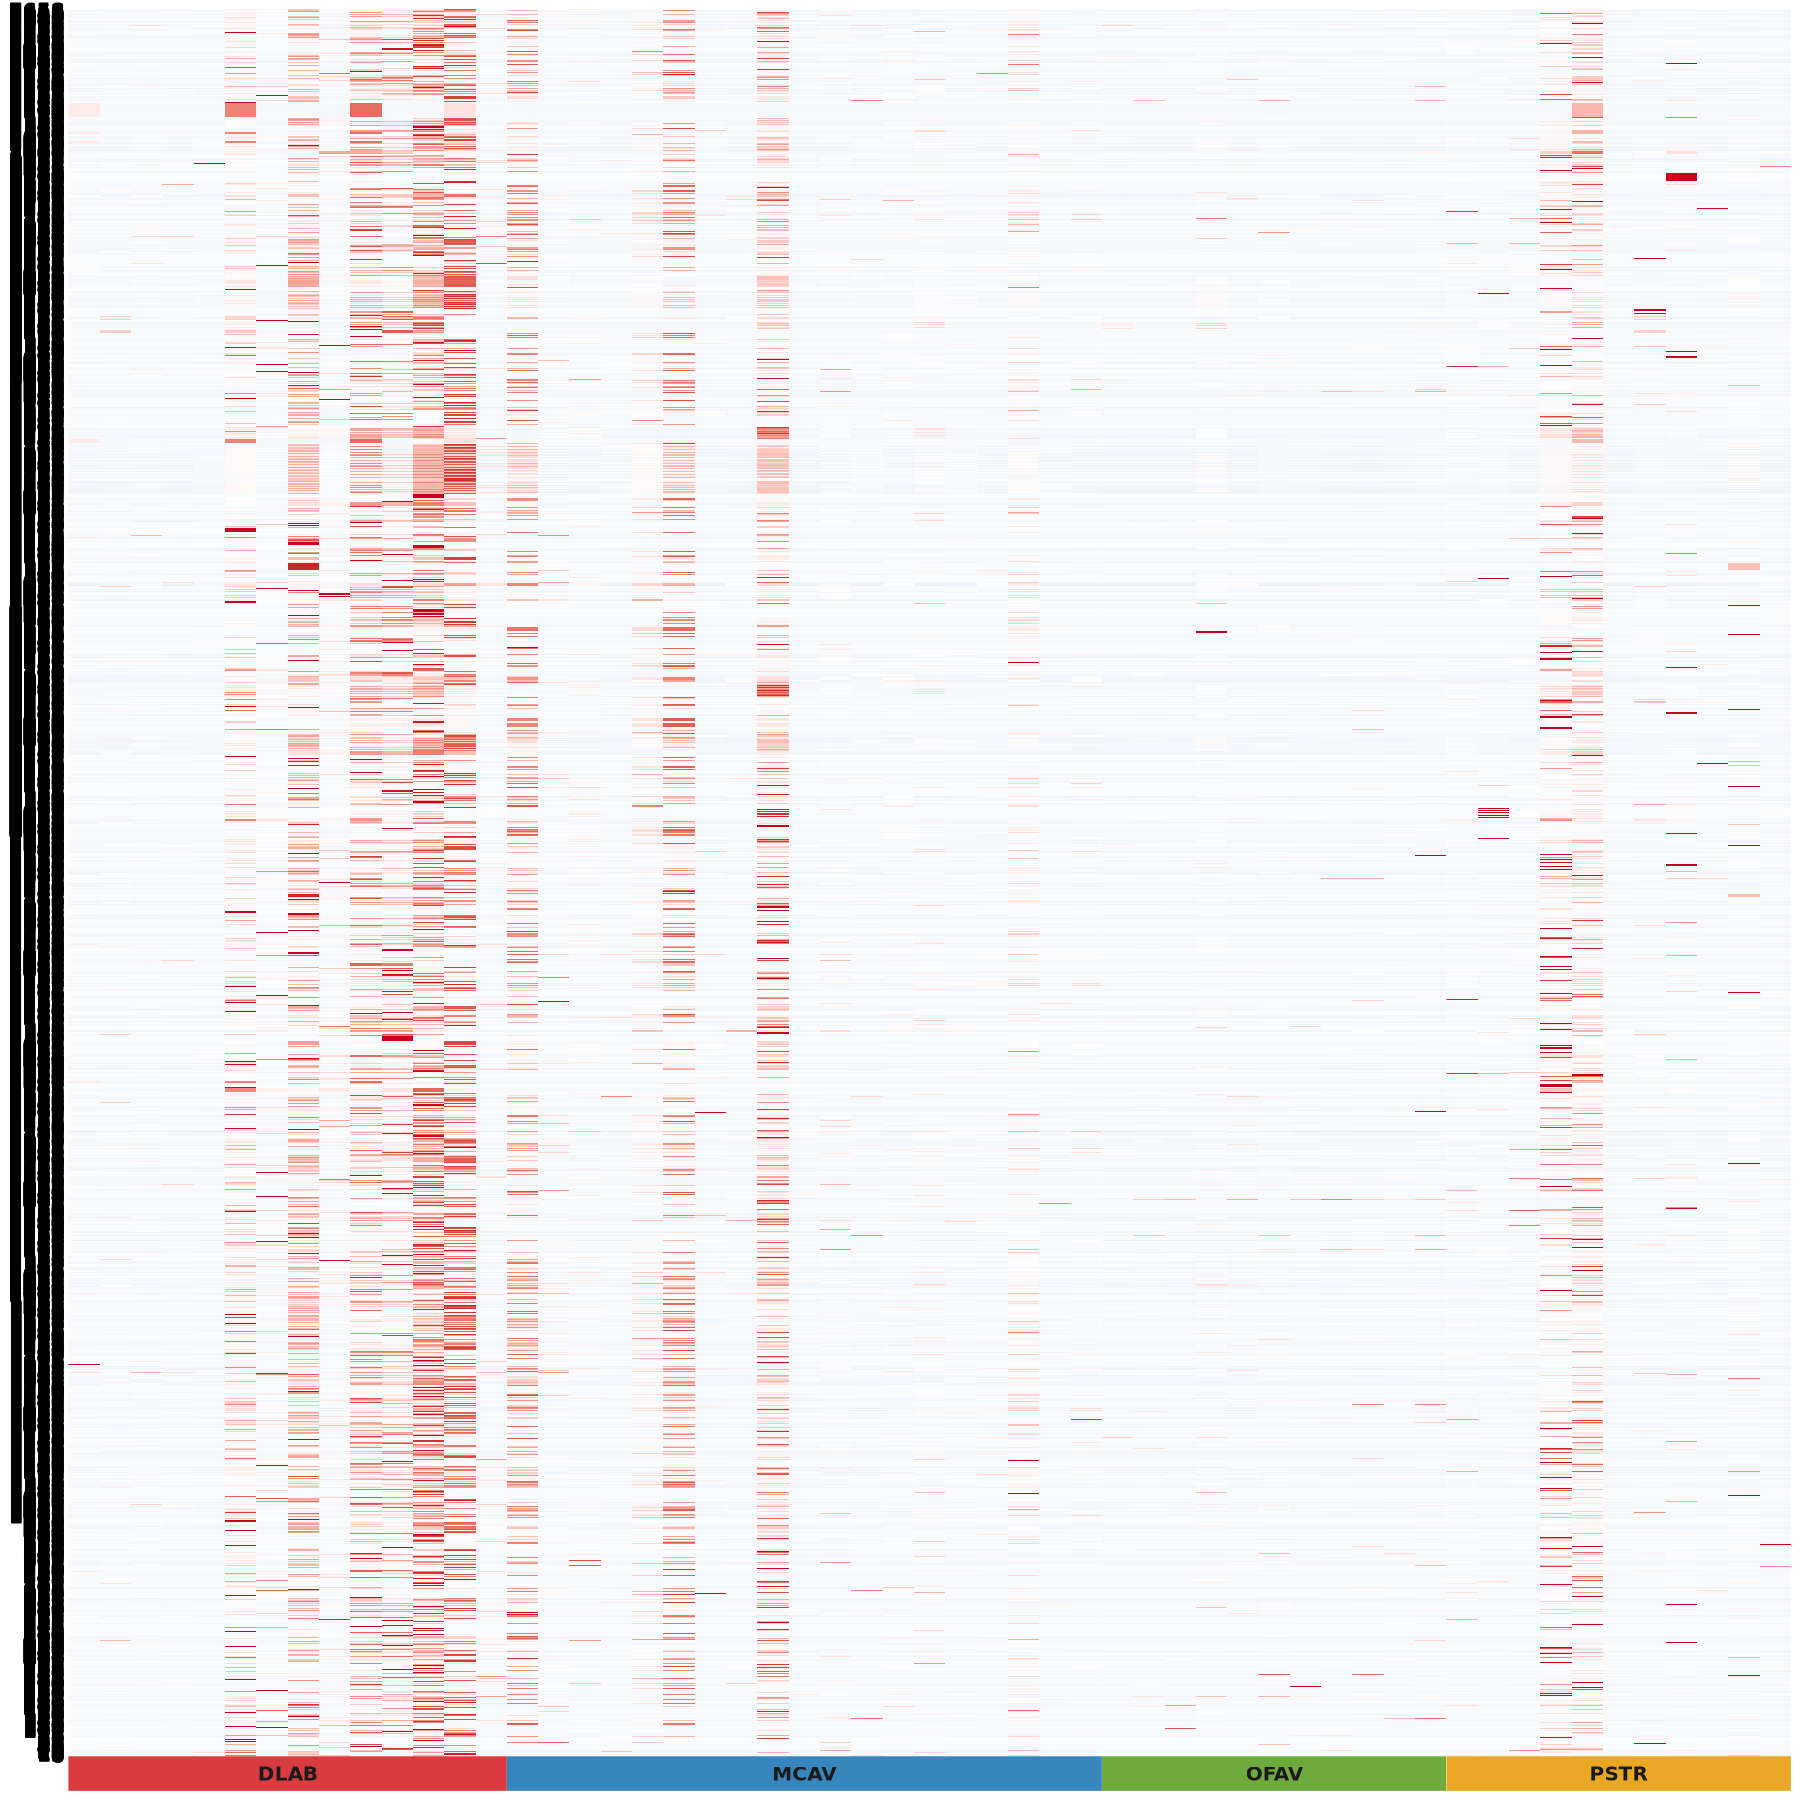

In [36]:
plot1 <- pathway_heatmap(genes_filtered_reordered_minuspstrS9_counts, metadata, "Species")
plot1

In [37]:
#calculate z-score 
mat_z <- t(scale(t(genes_filtered_reordered_minuspstrS9_counts)))

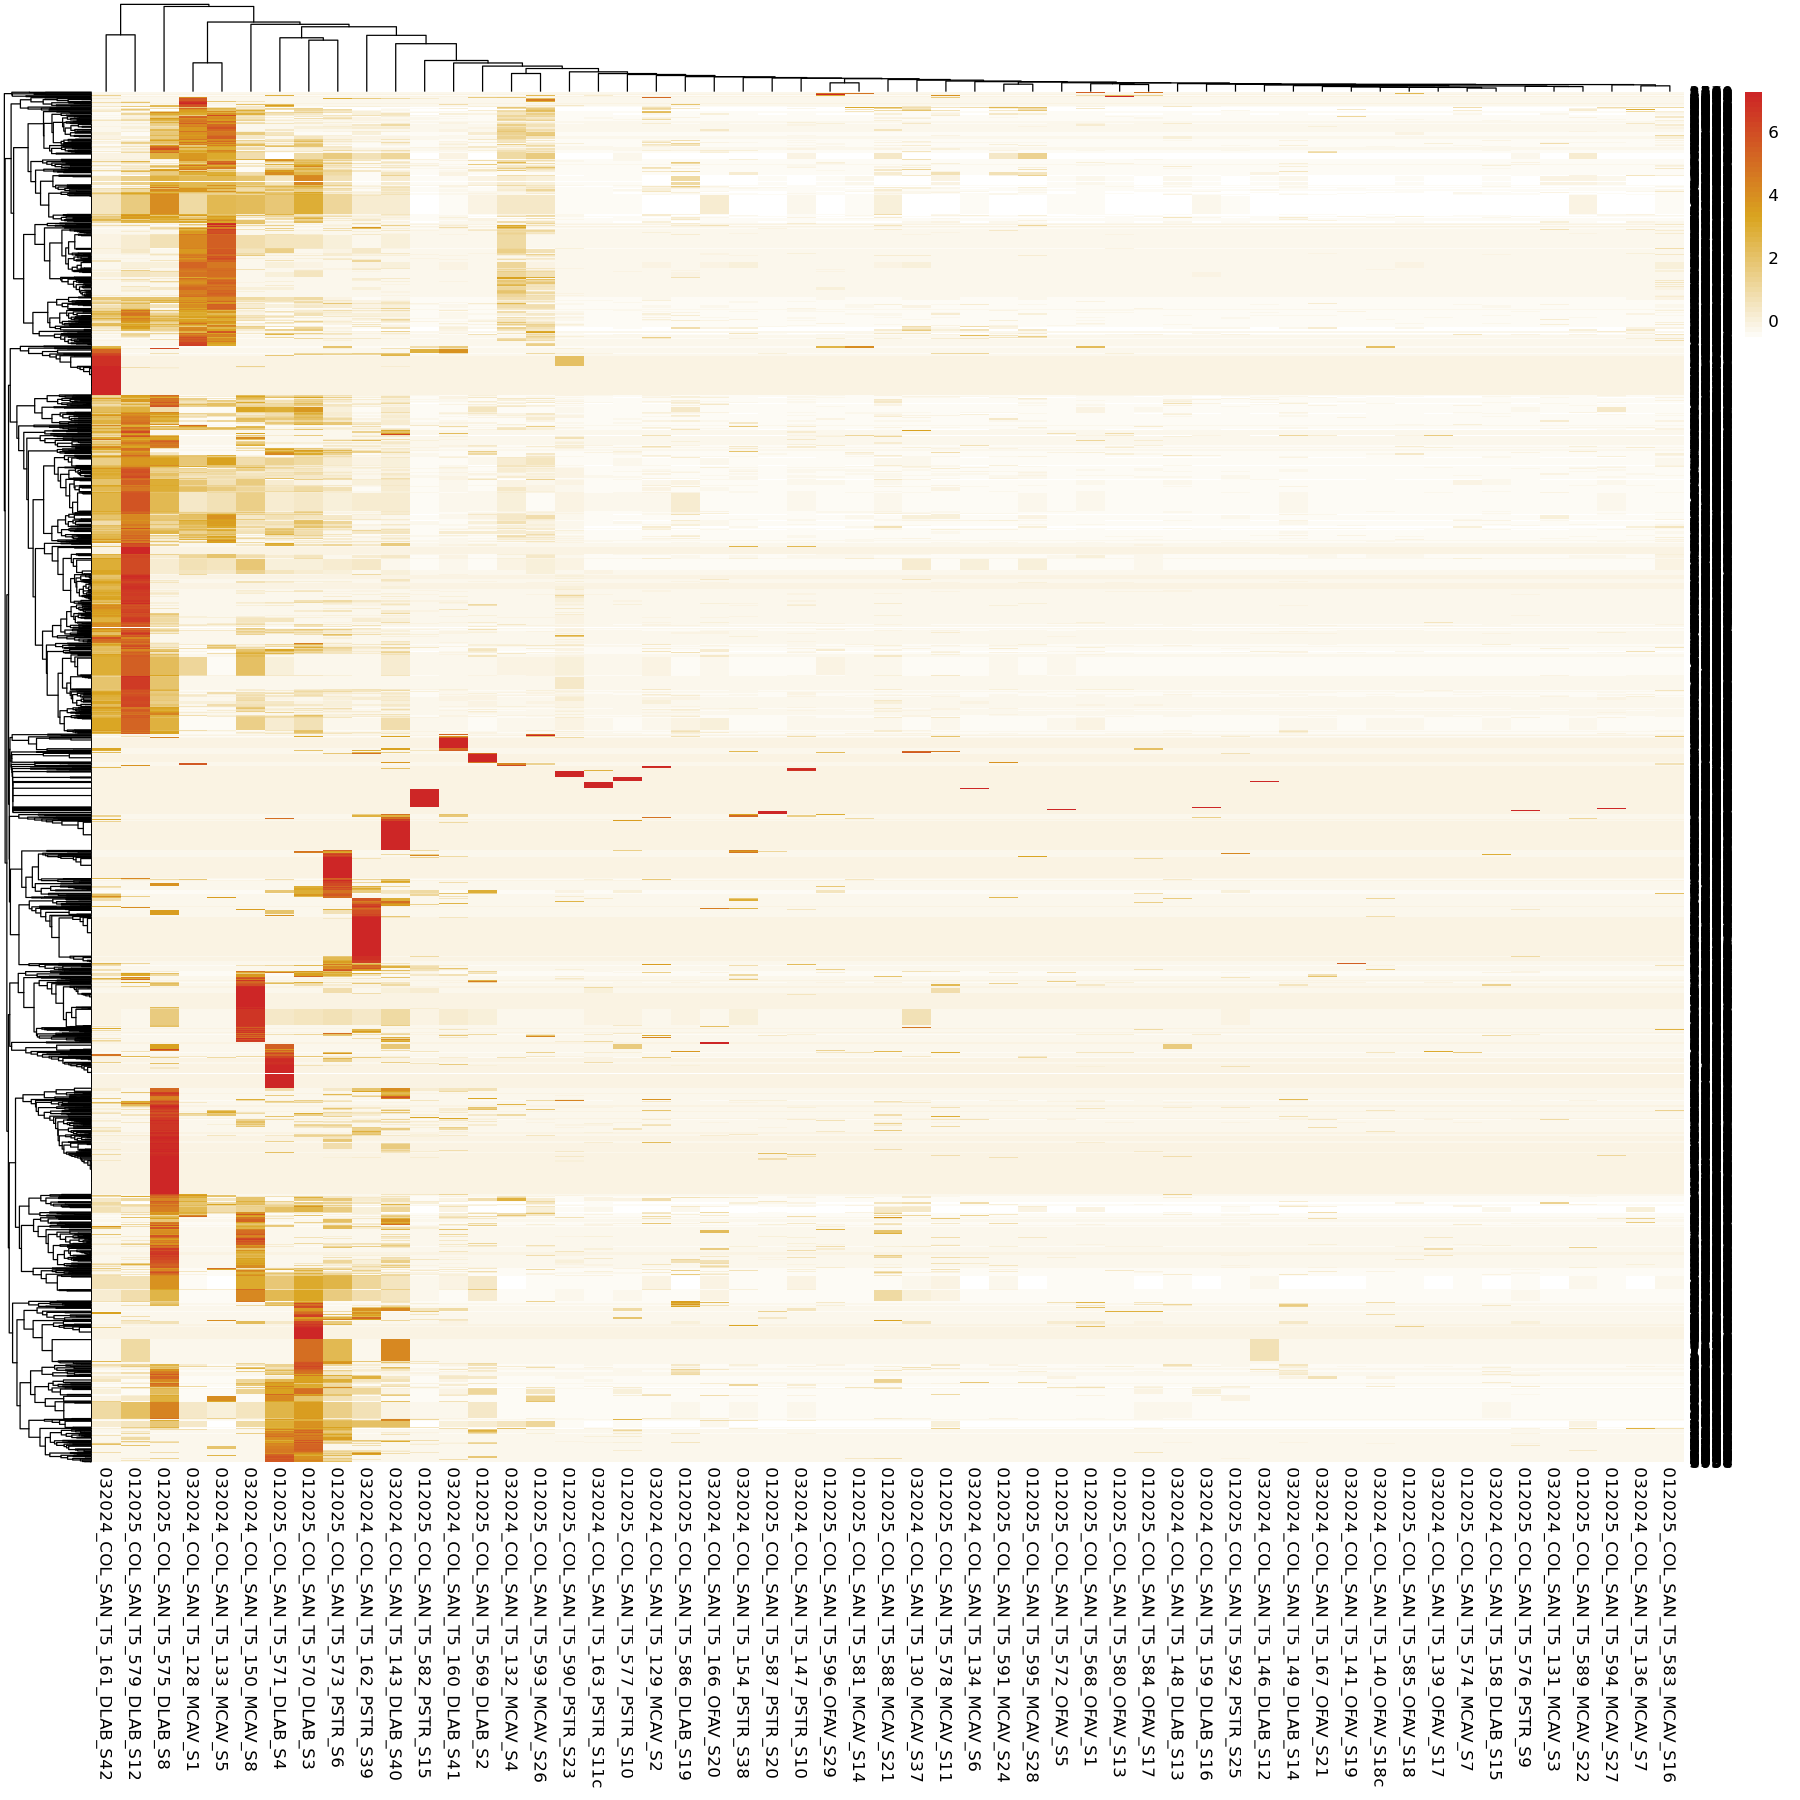

In [43]:
pheatmap(mat_z, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colorRampPalette(c("white", "goldenrod", "firebrick3"))(50))

In [ ]:
#do separately by species?
#group by species and then by year?